Pyfeatの顔検出信頼度プロット

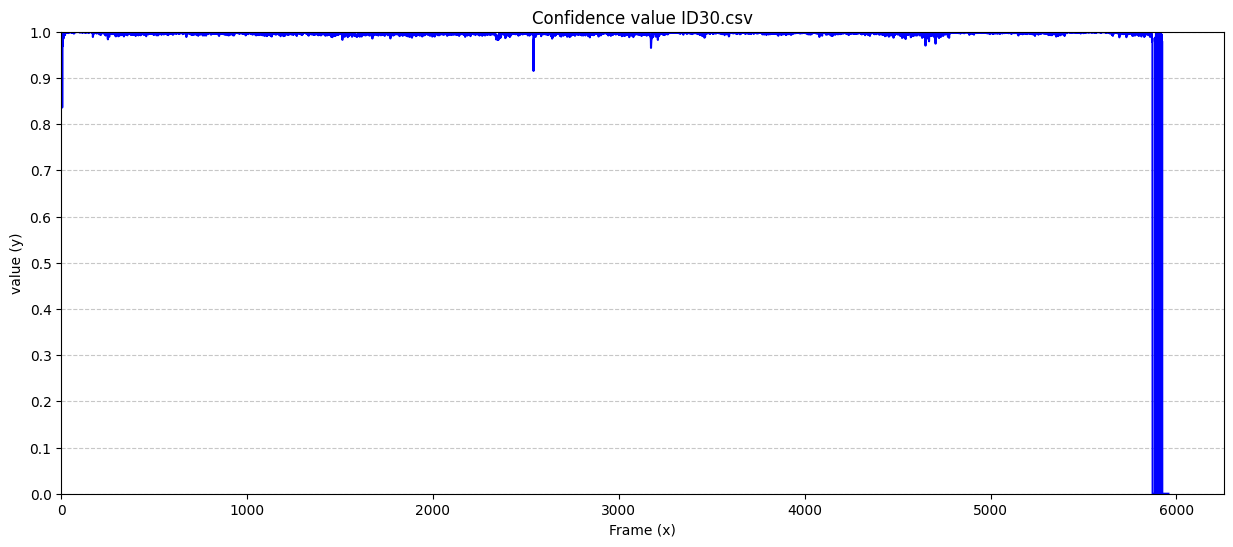

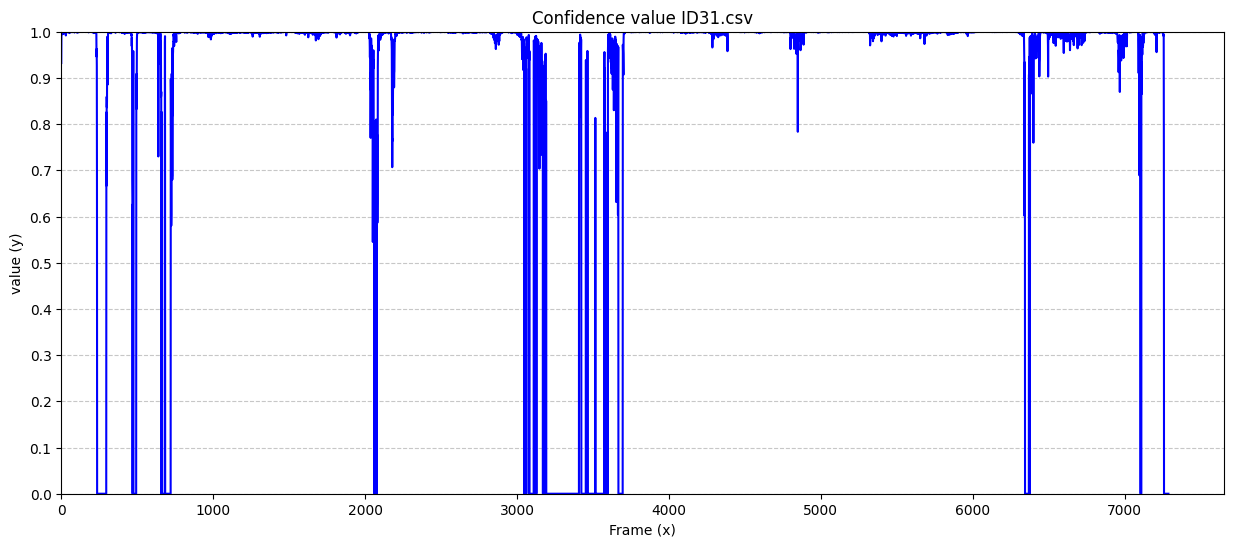

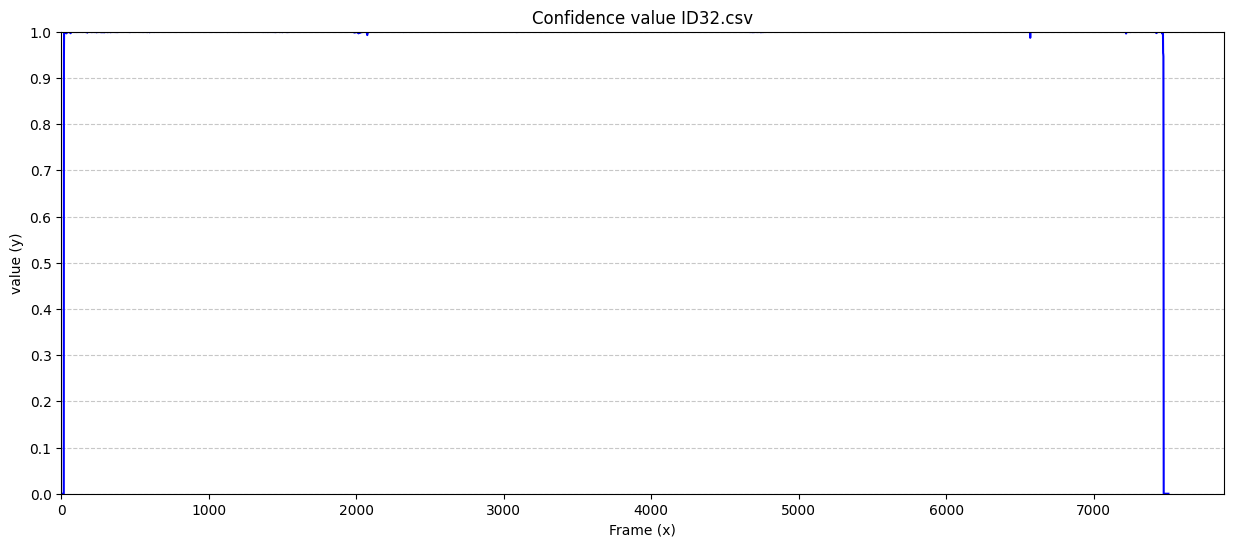

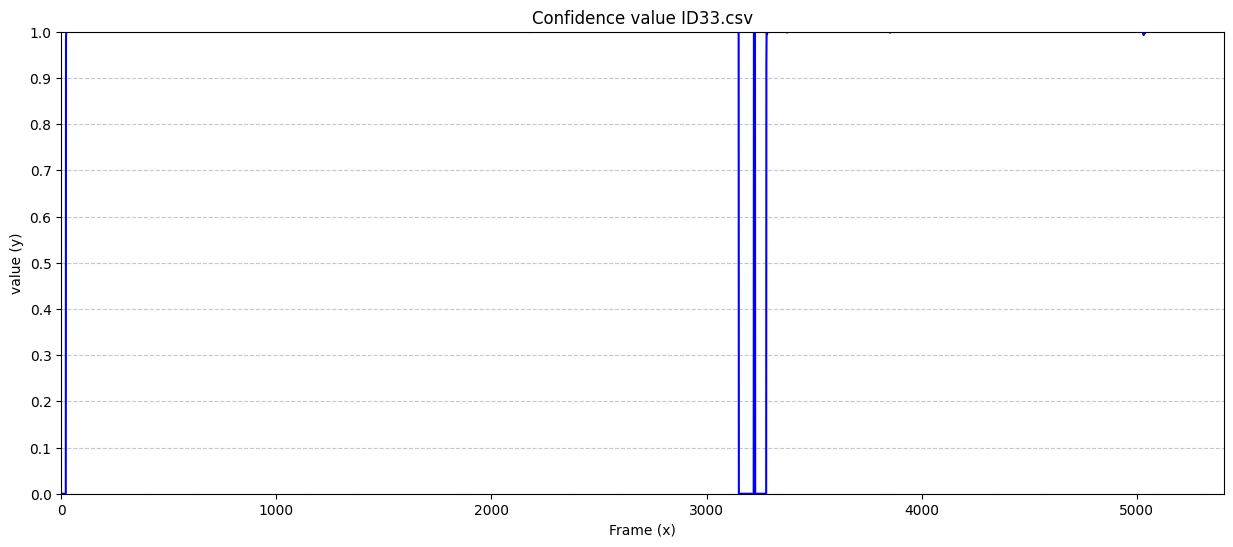

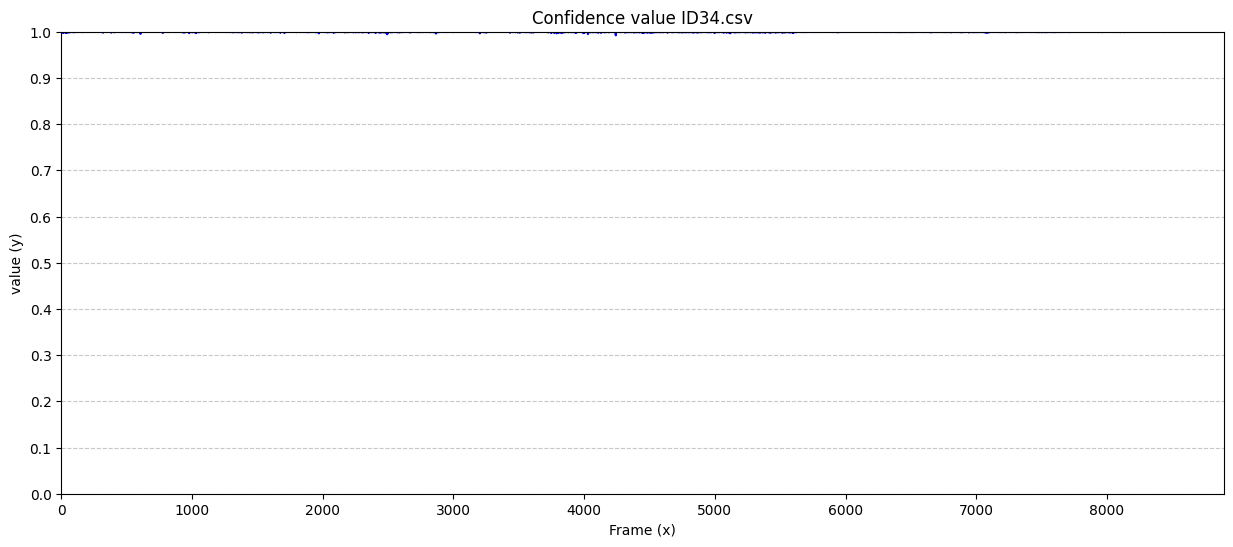

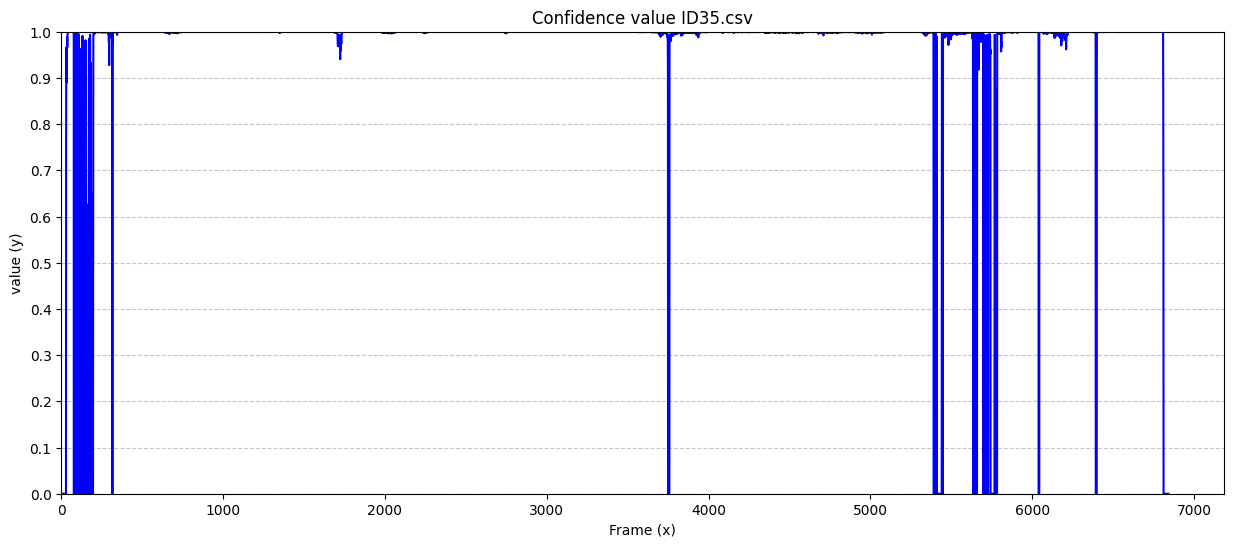

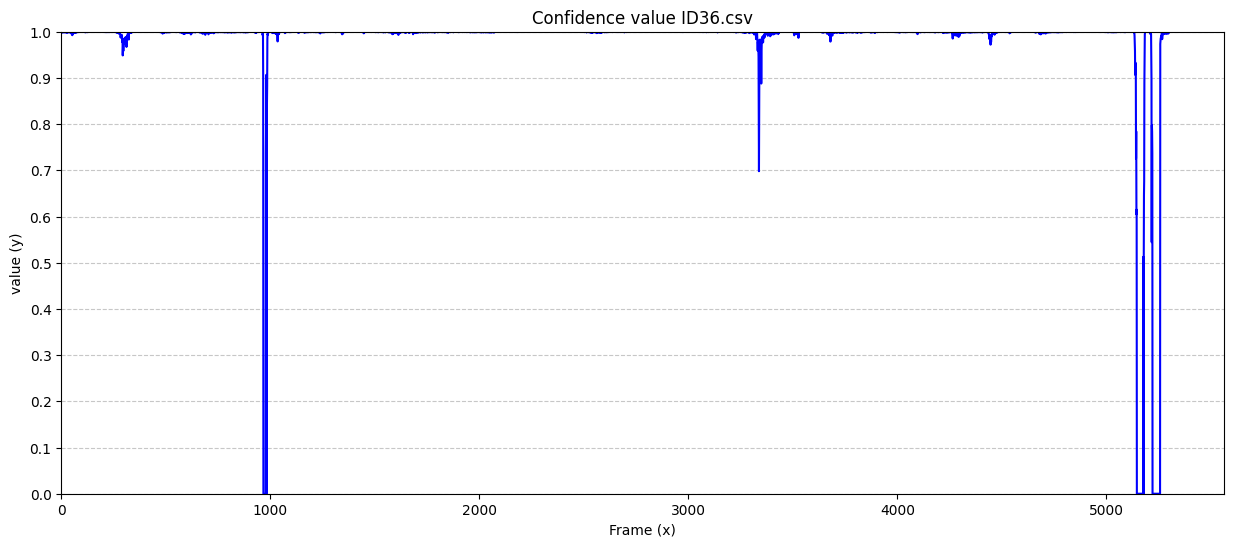

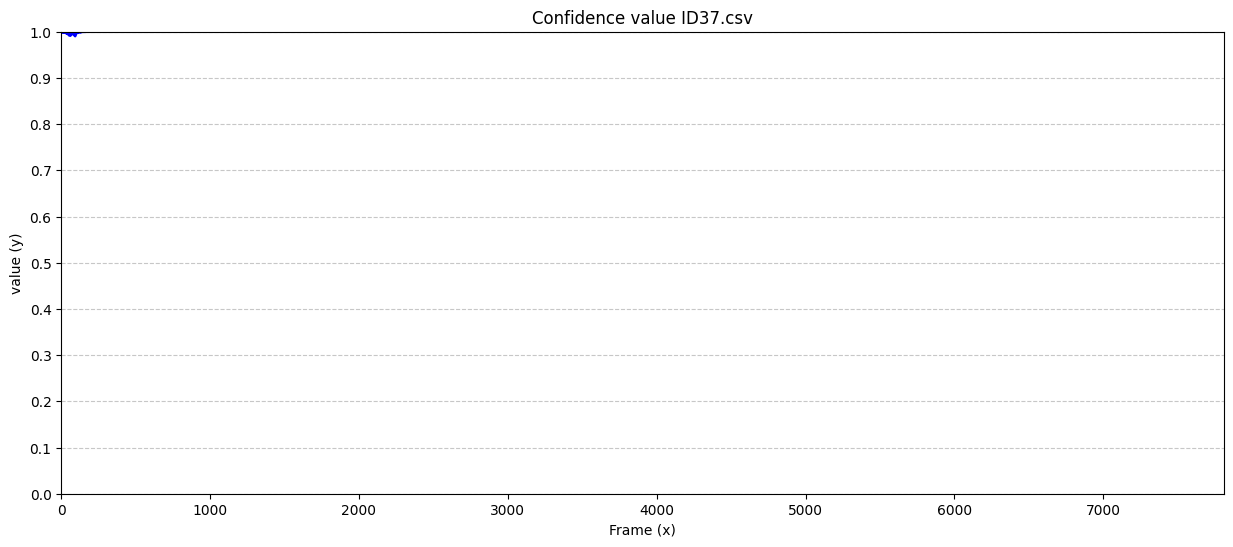

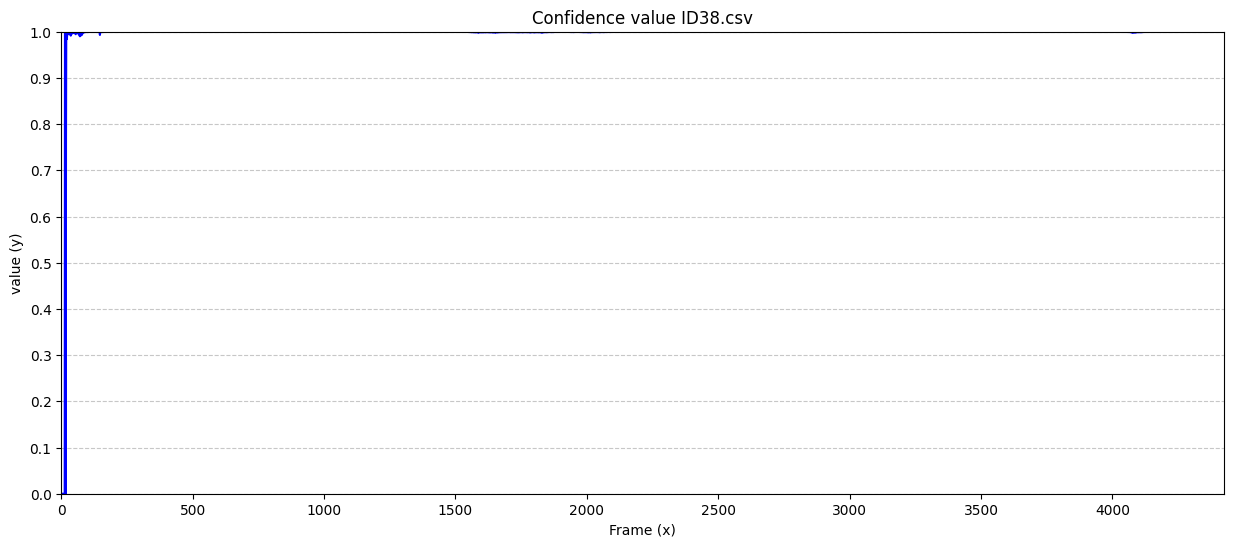

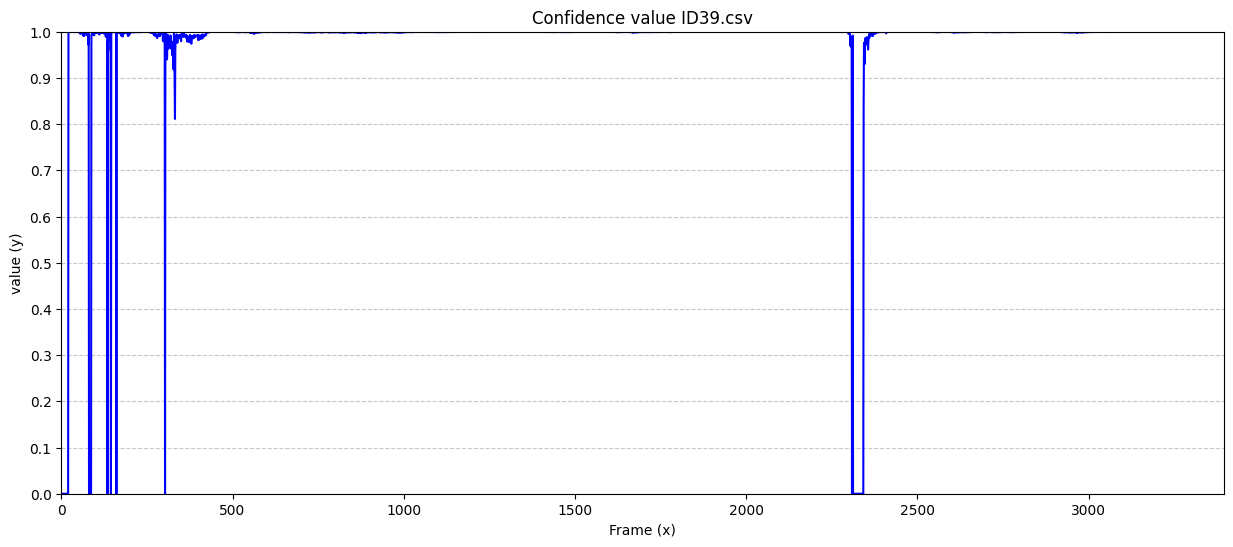

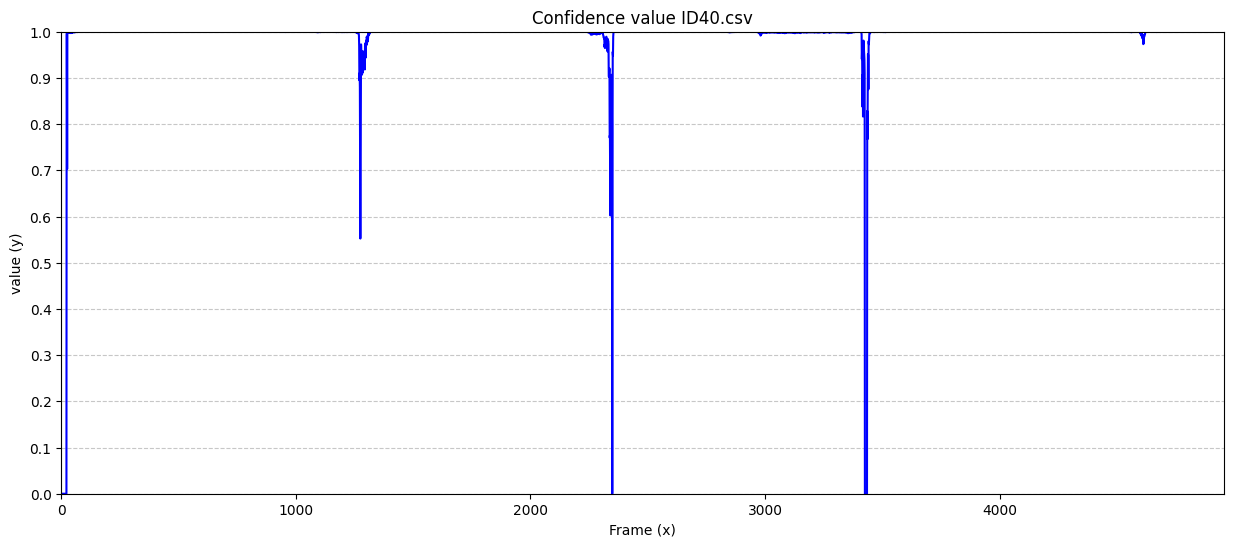

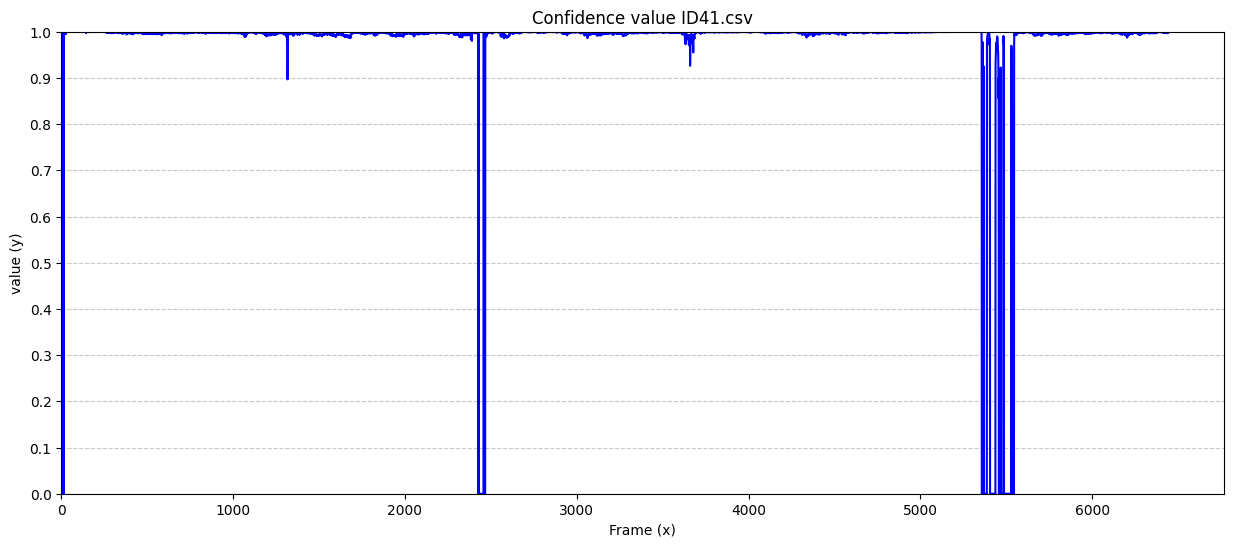

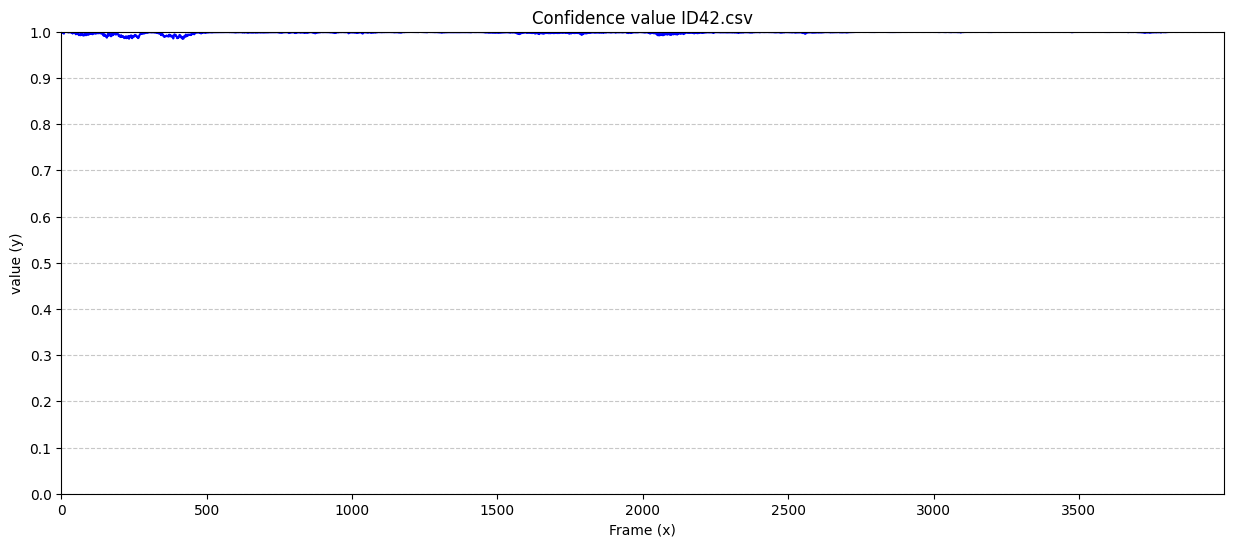

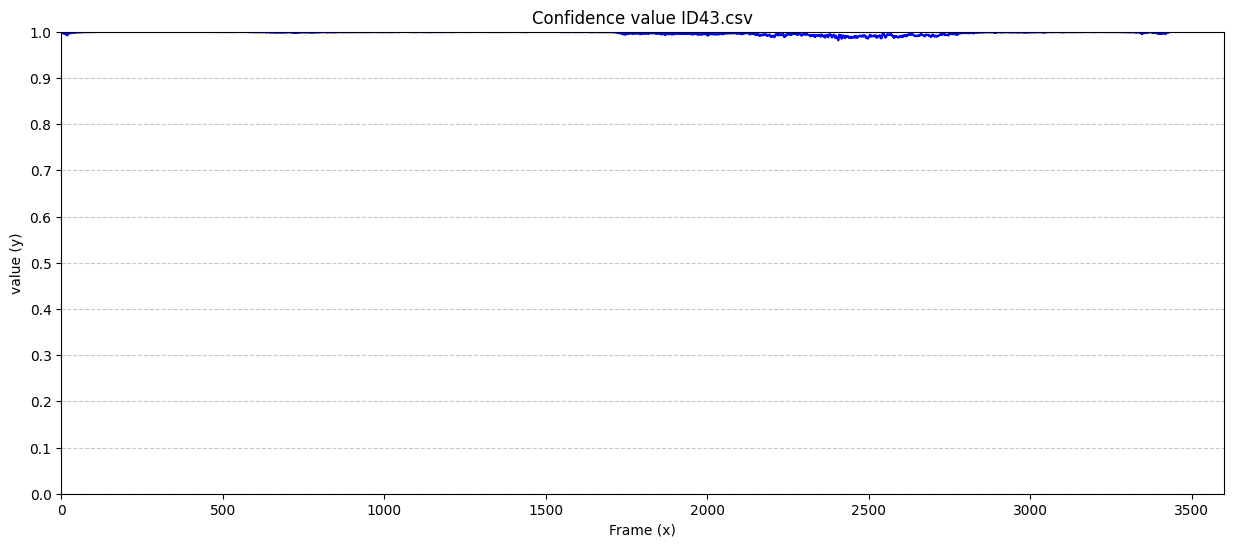

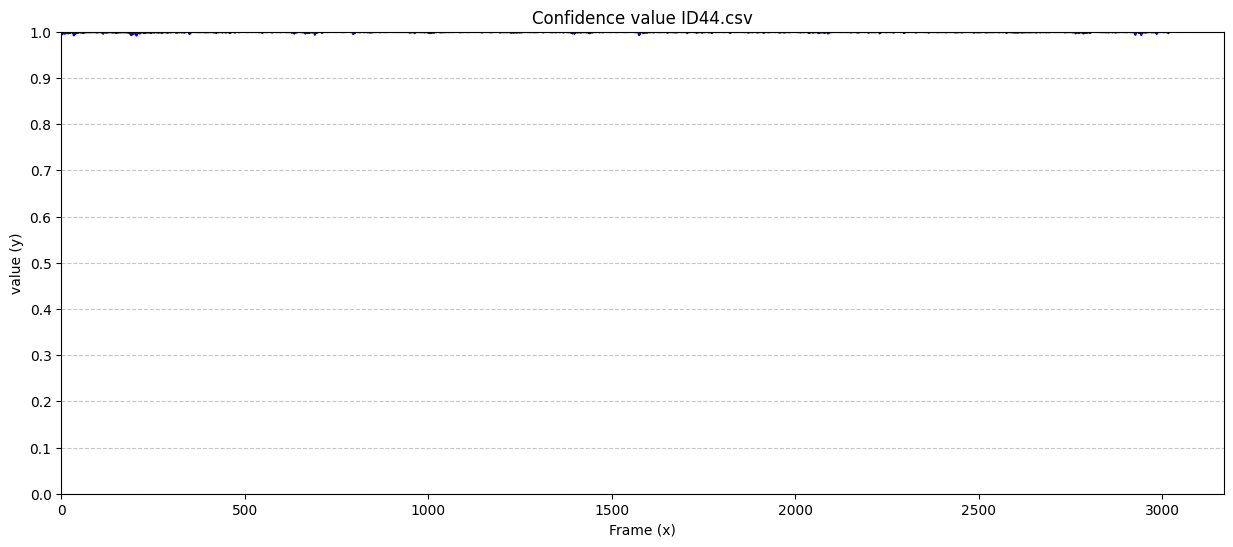

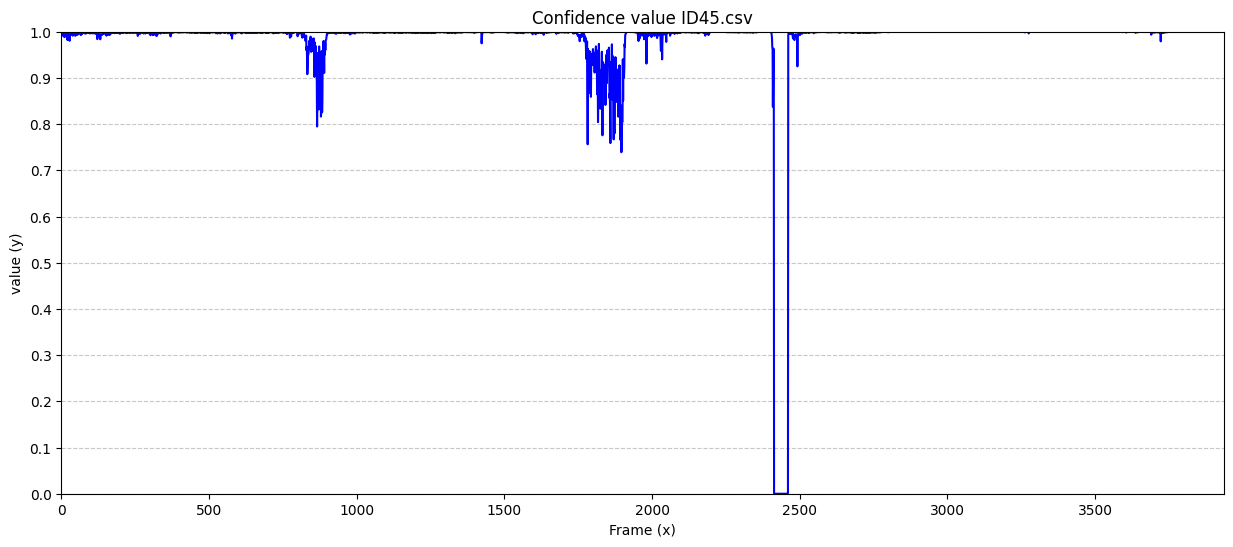

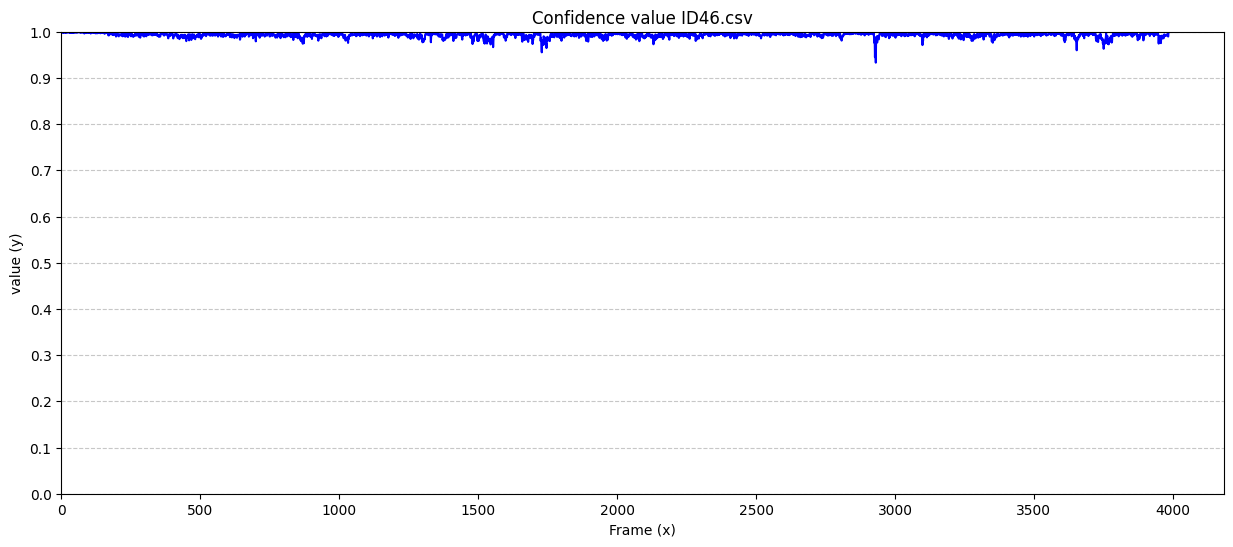

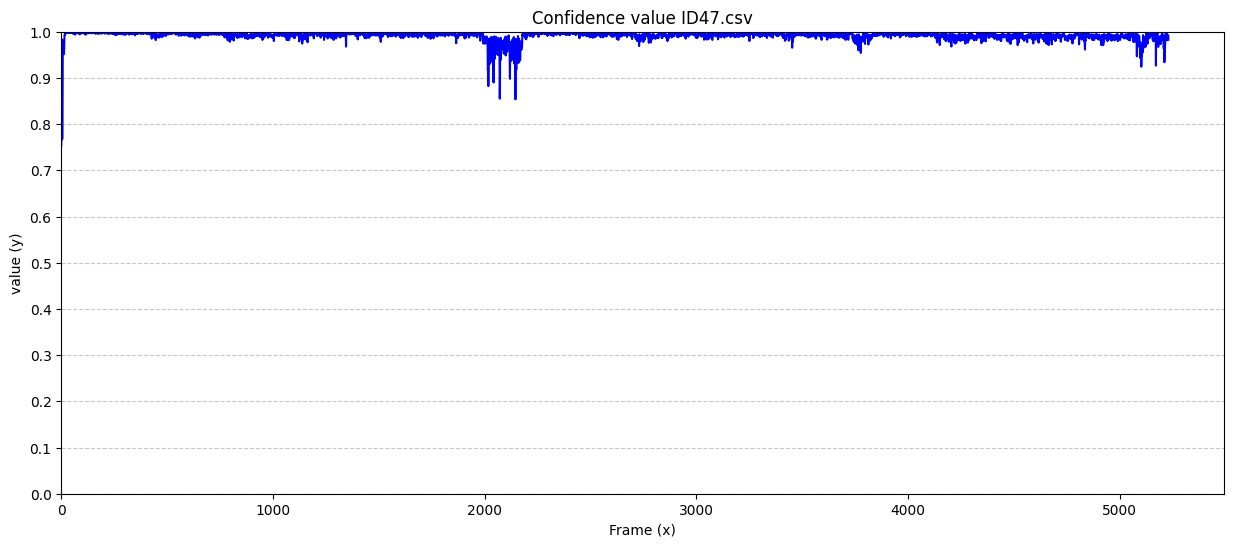

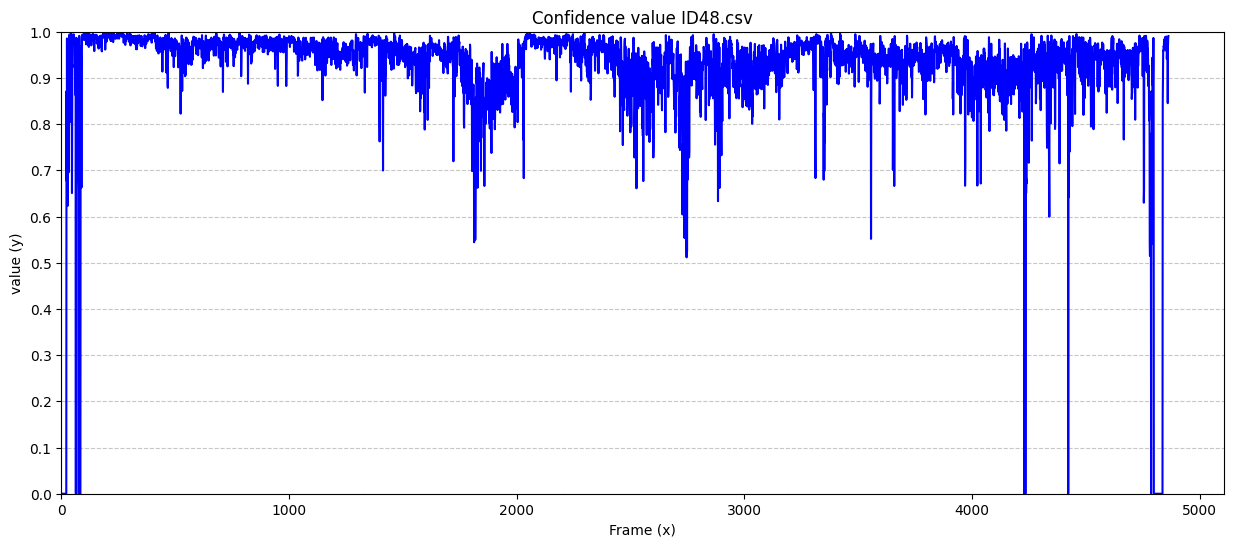

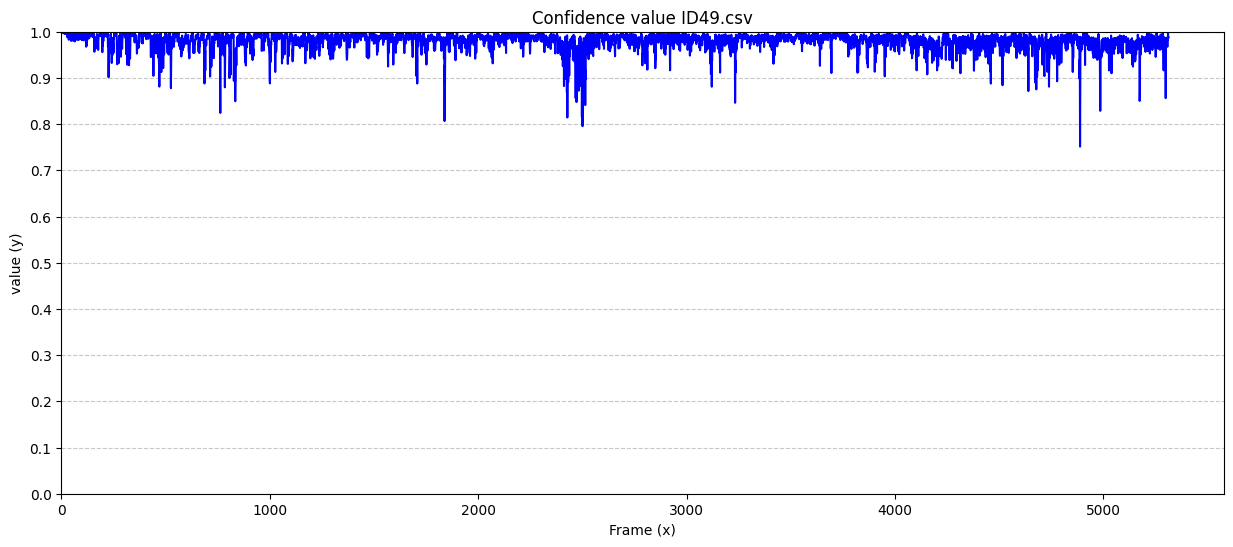

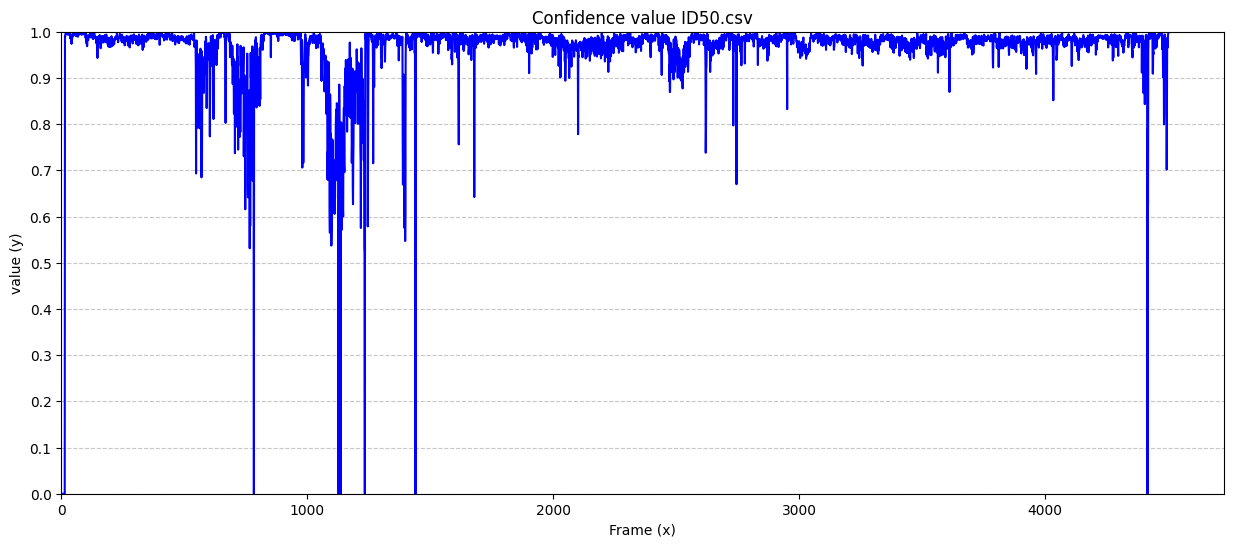

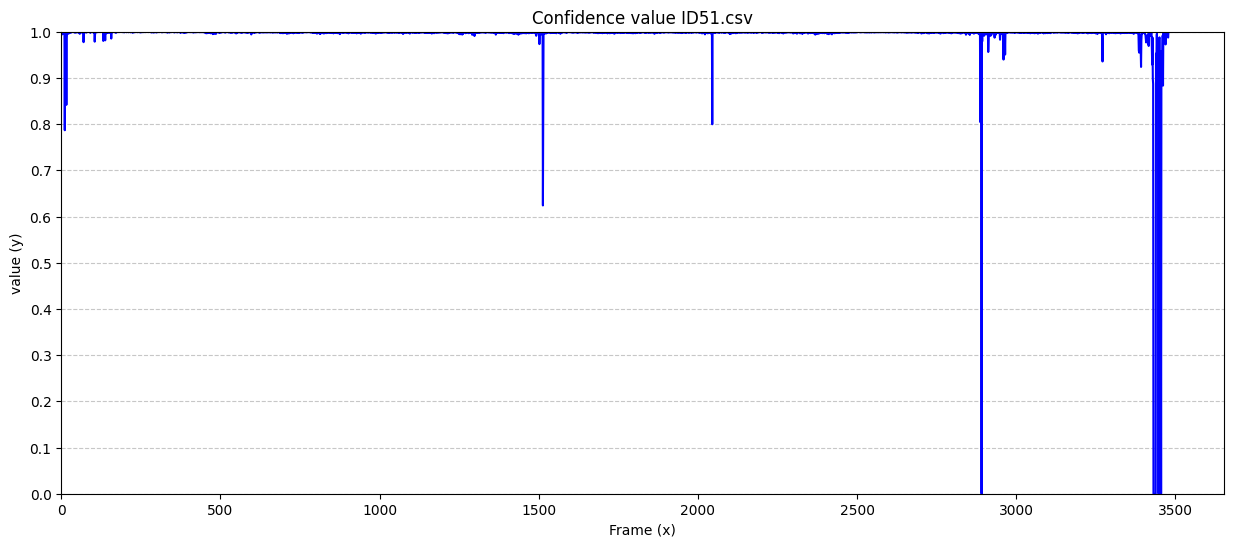

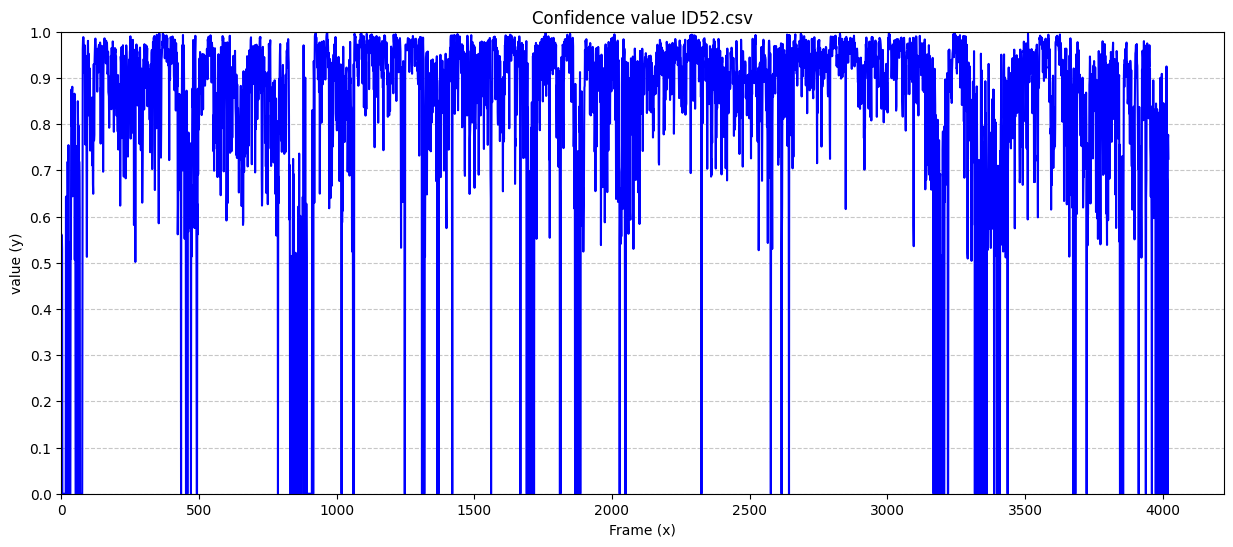

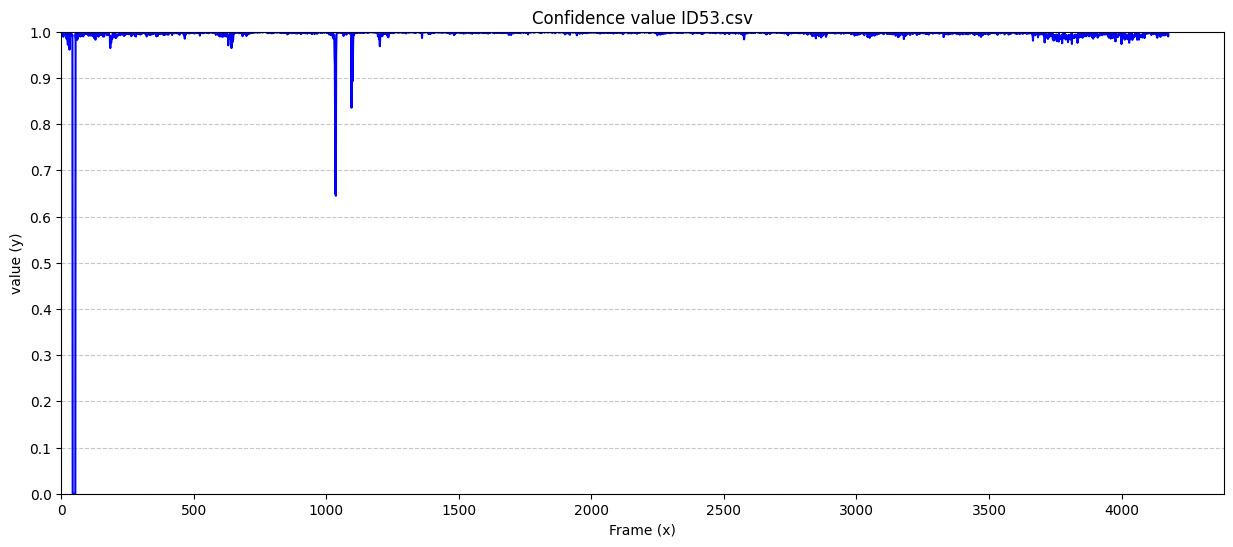

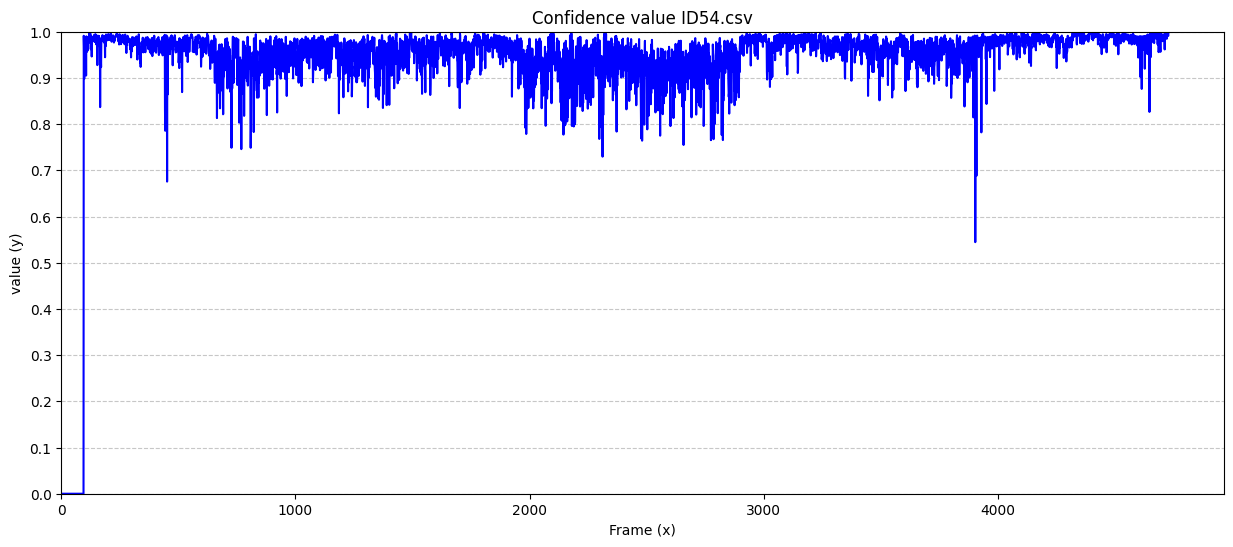

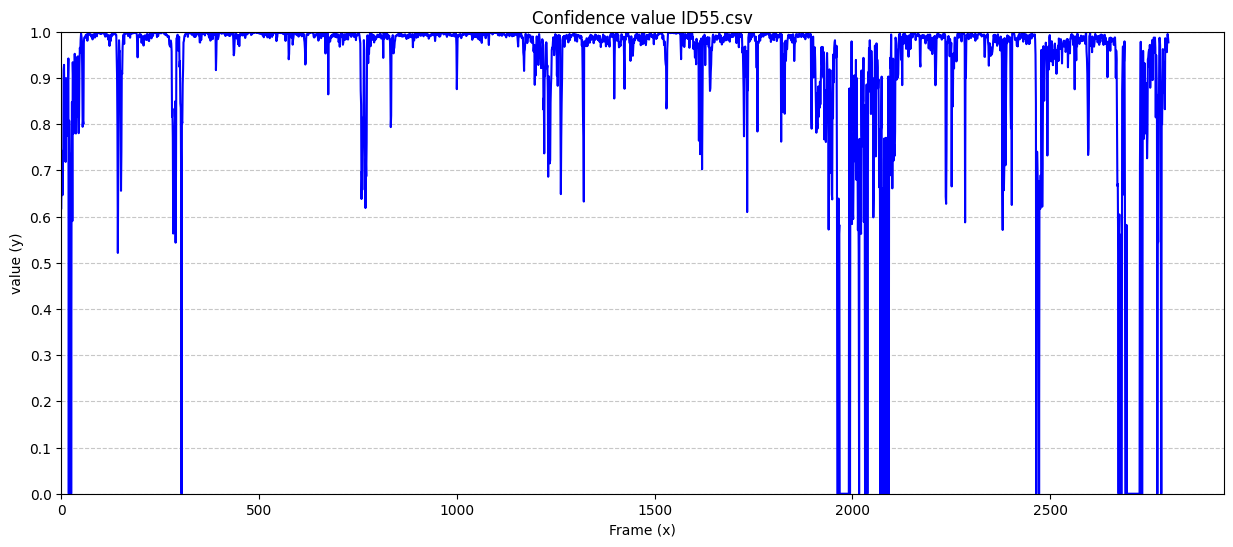

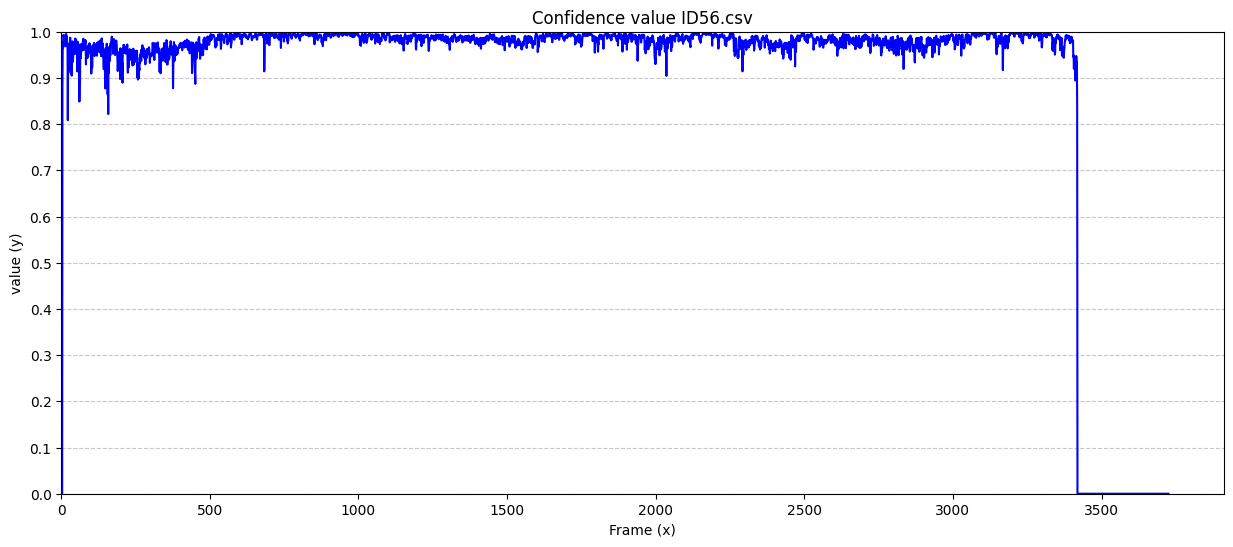

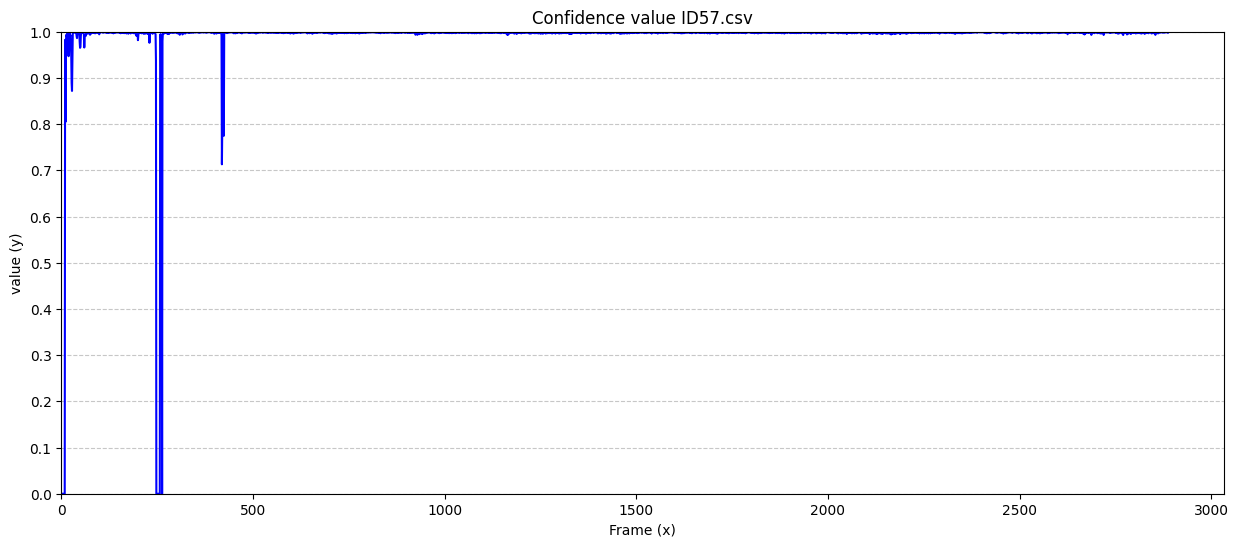

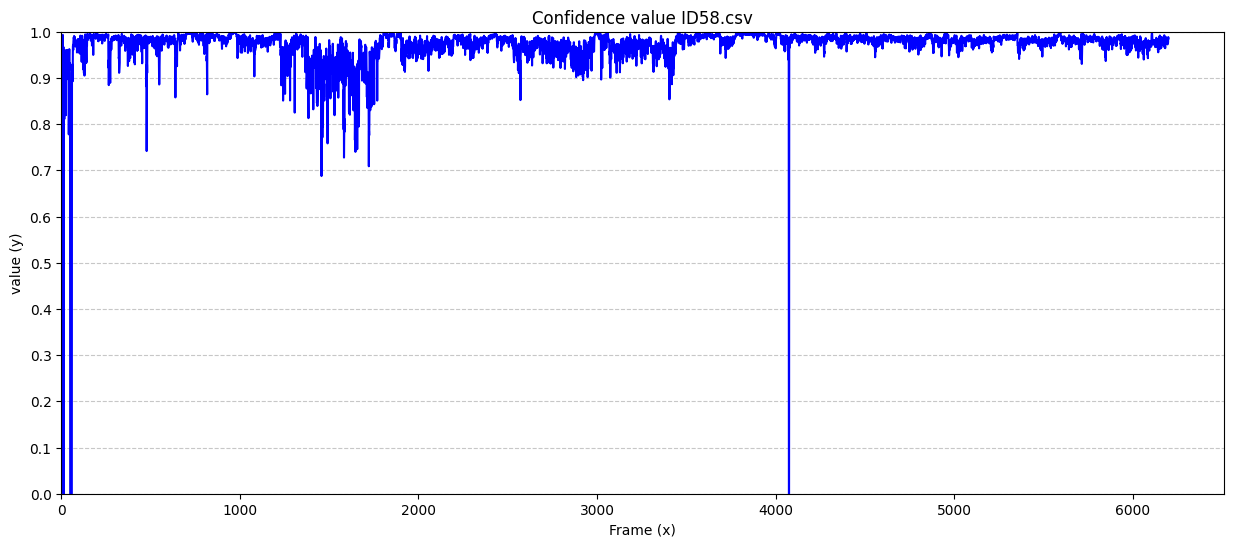

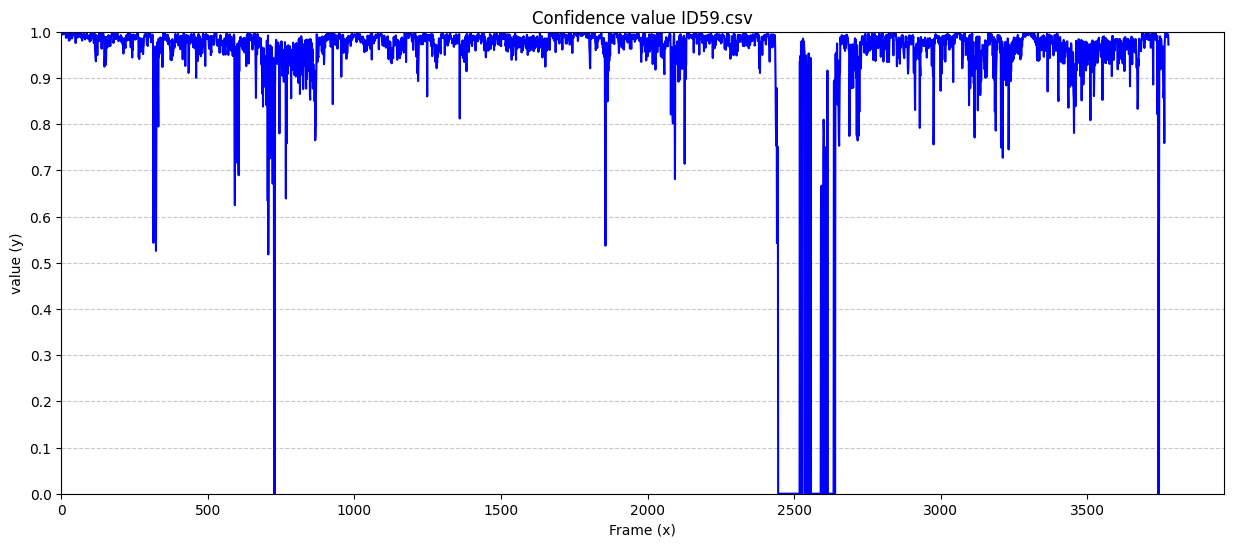

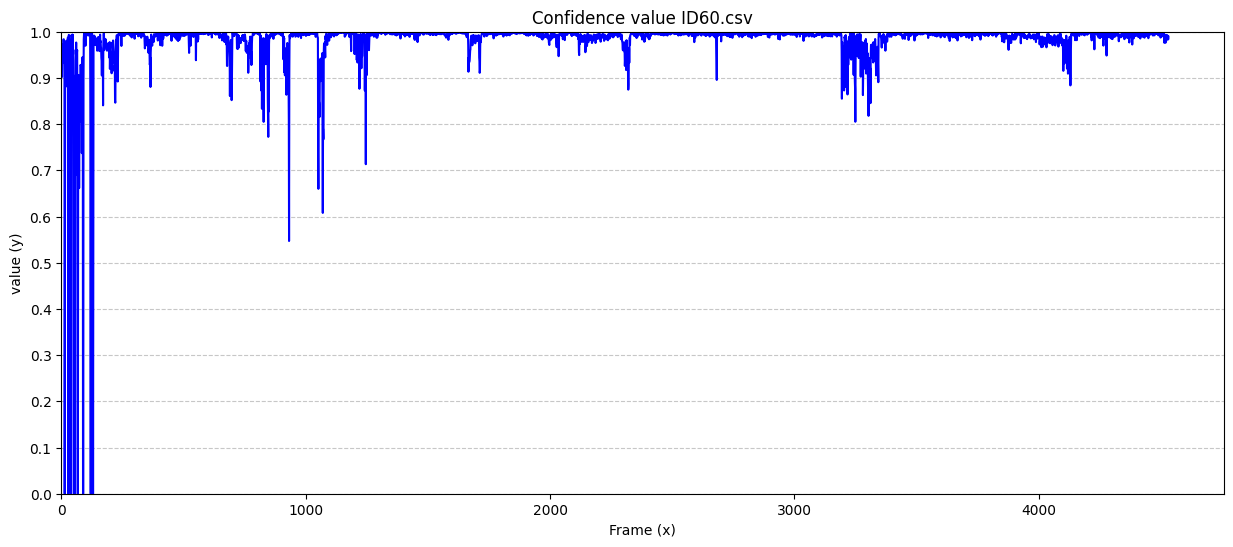

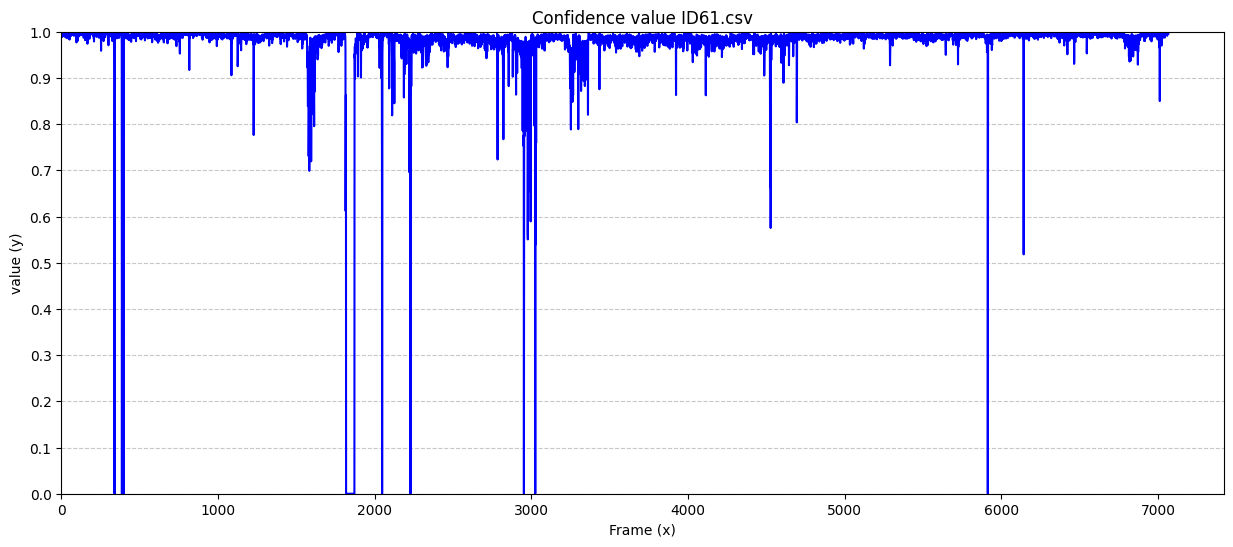

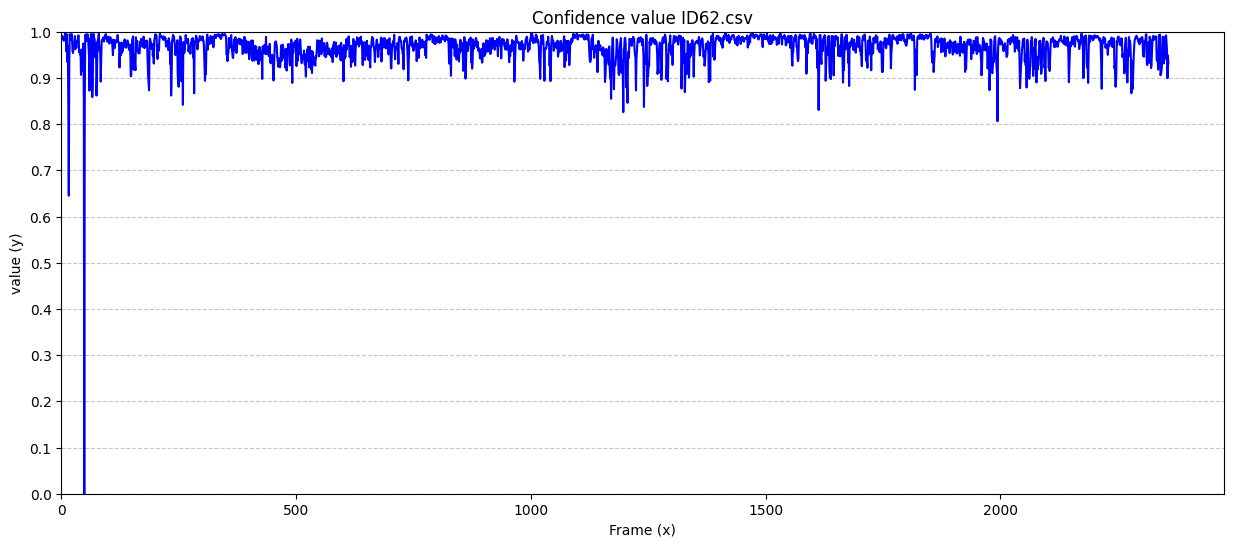

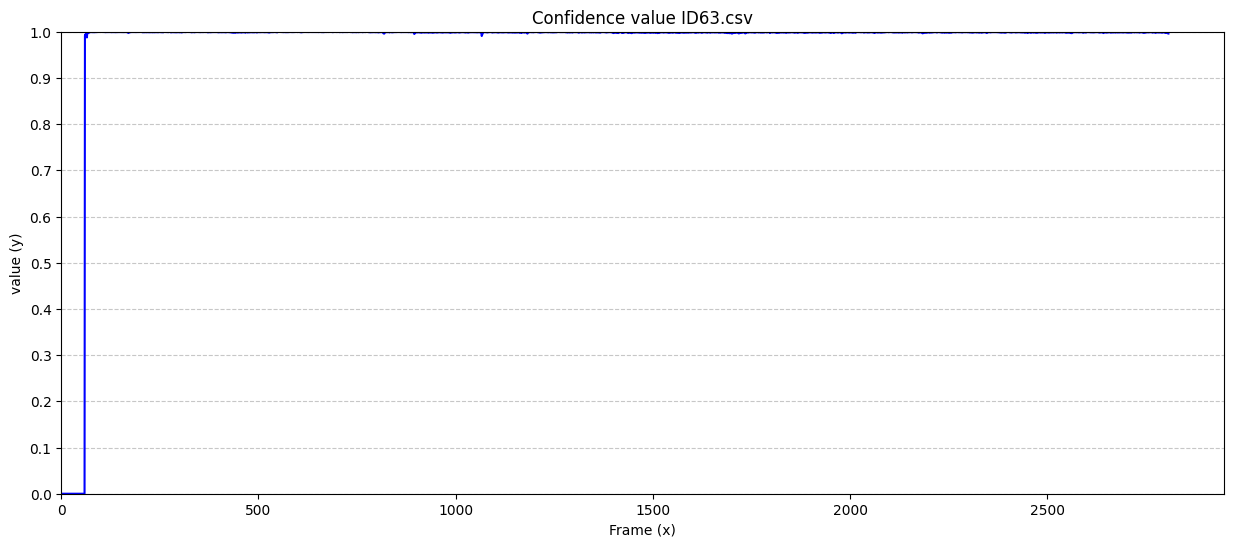

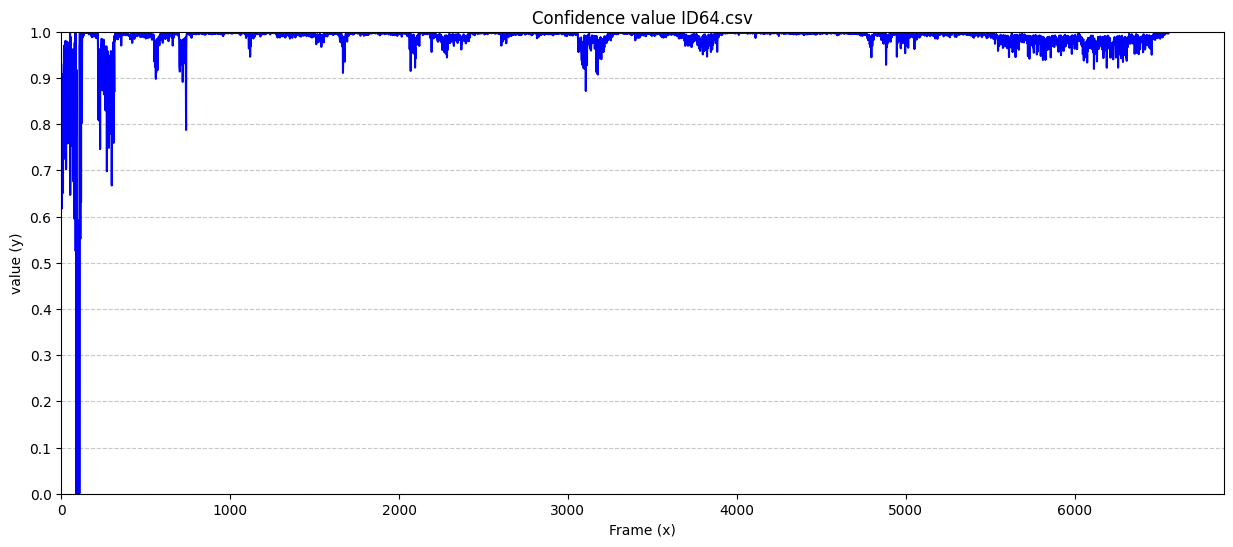

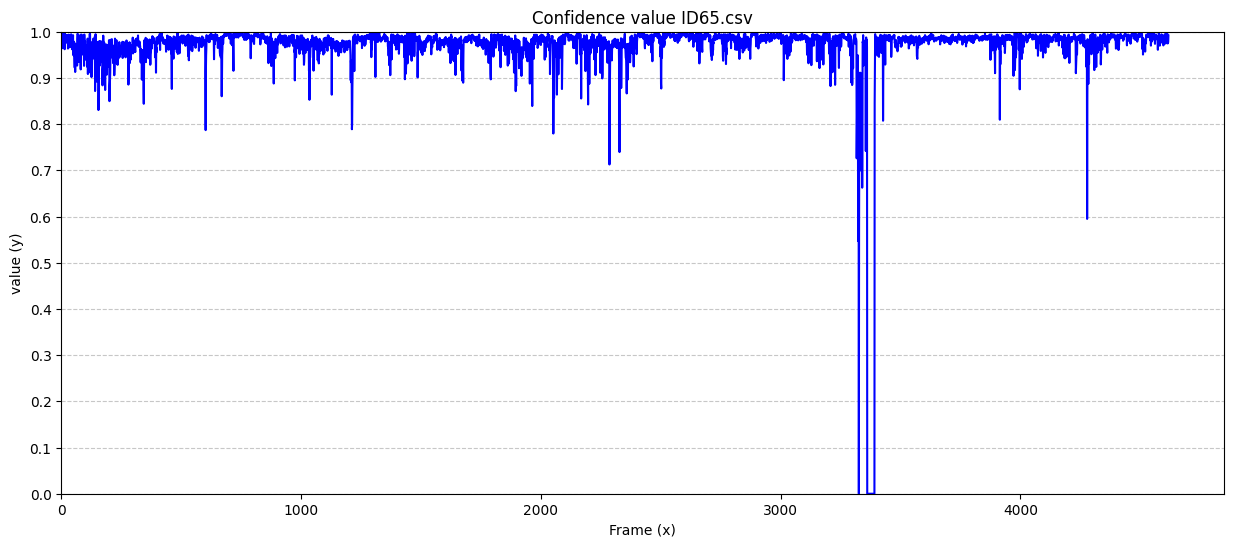

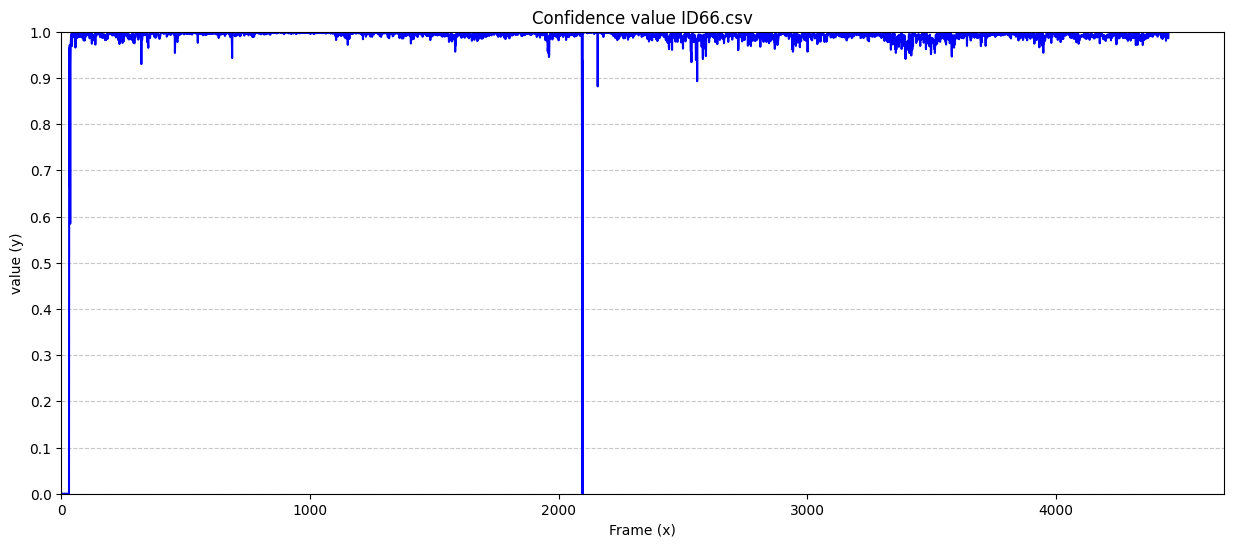

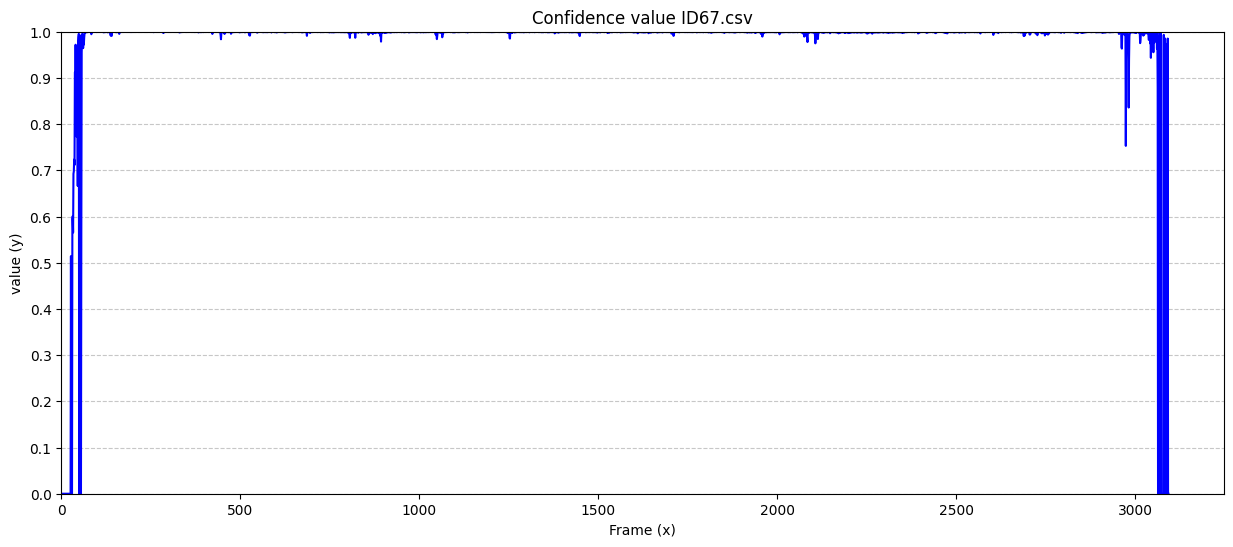

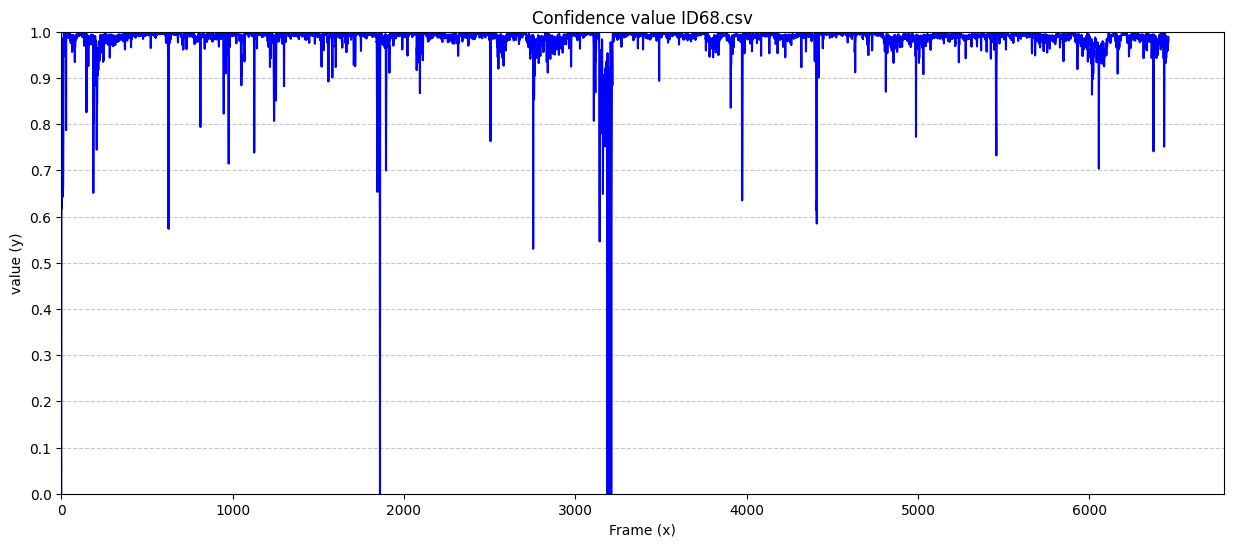

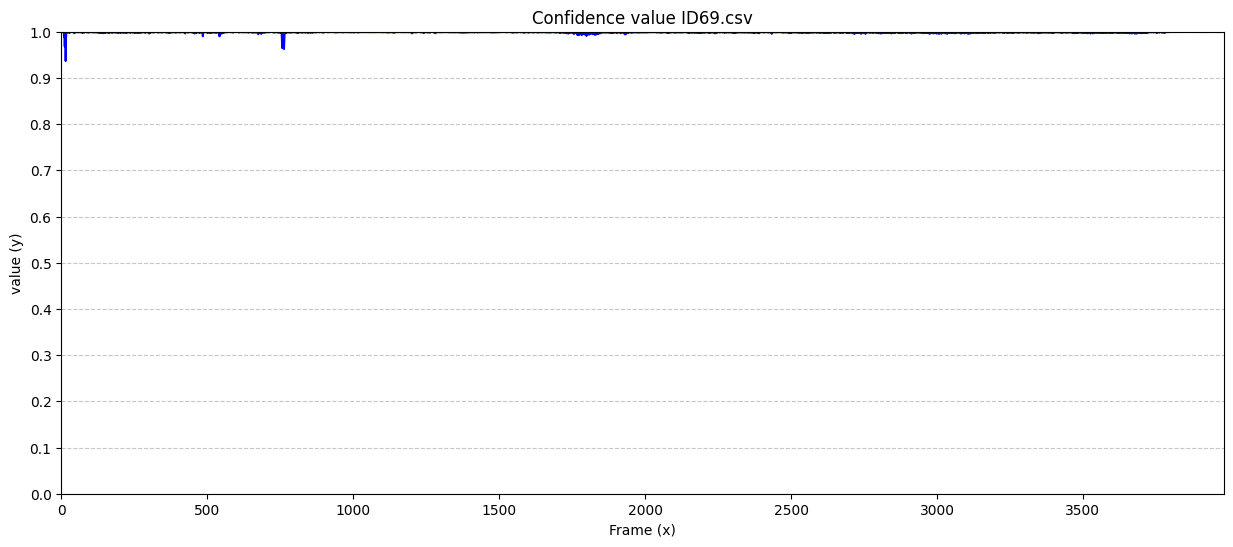

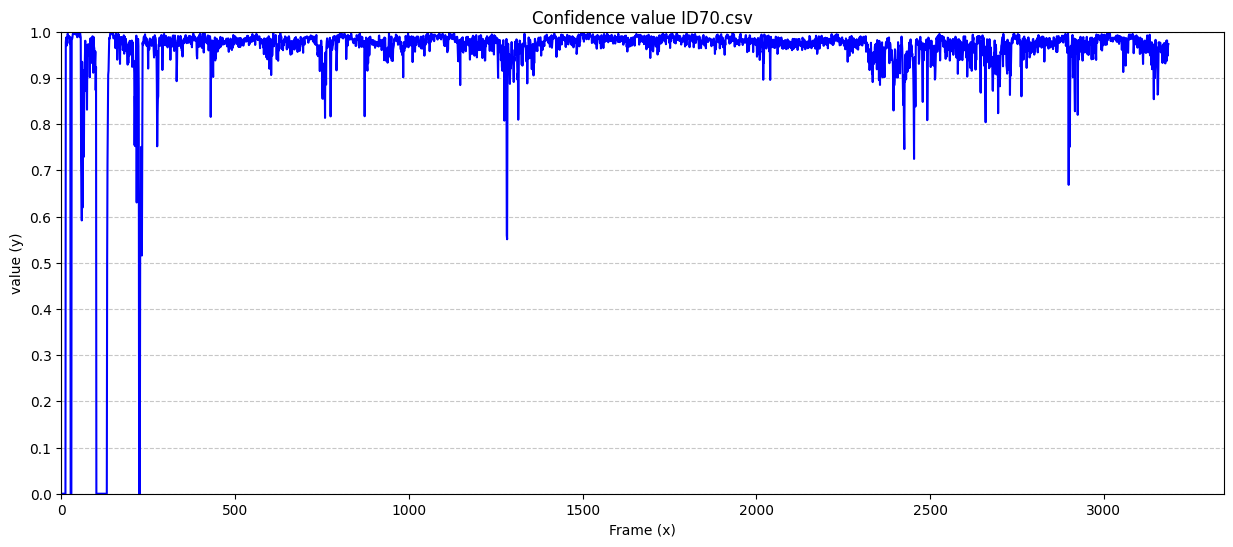

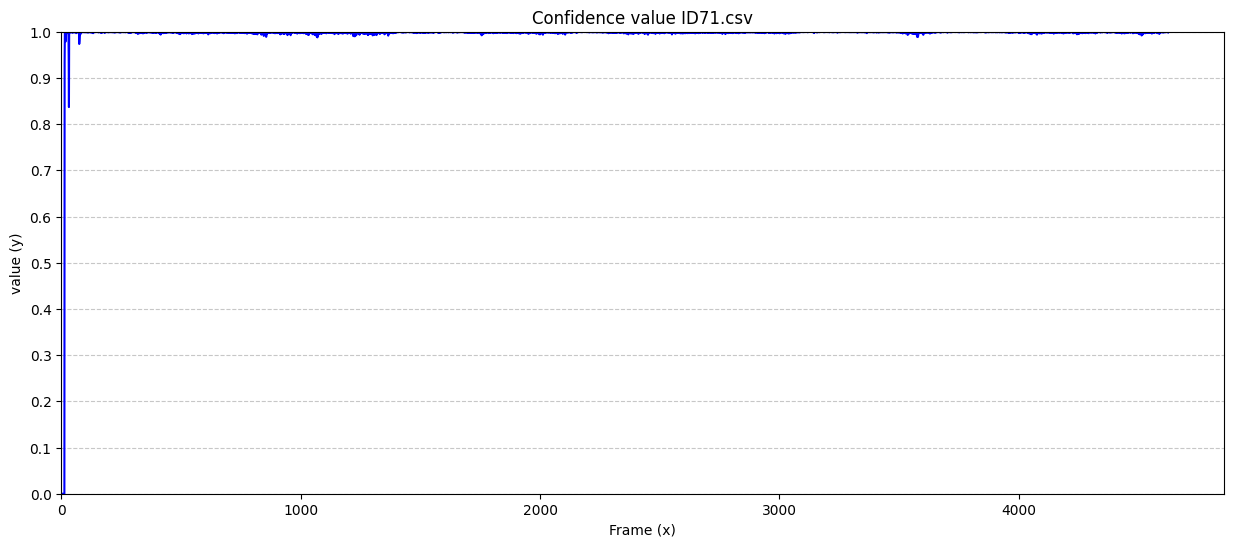

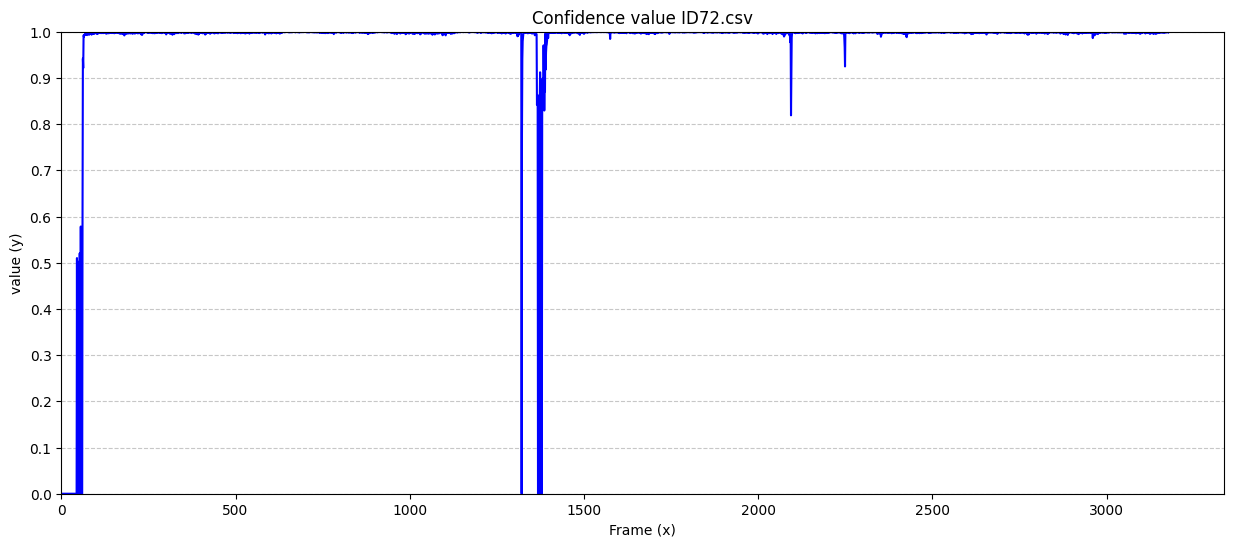

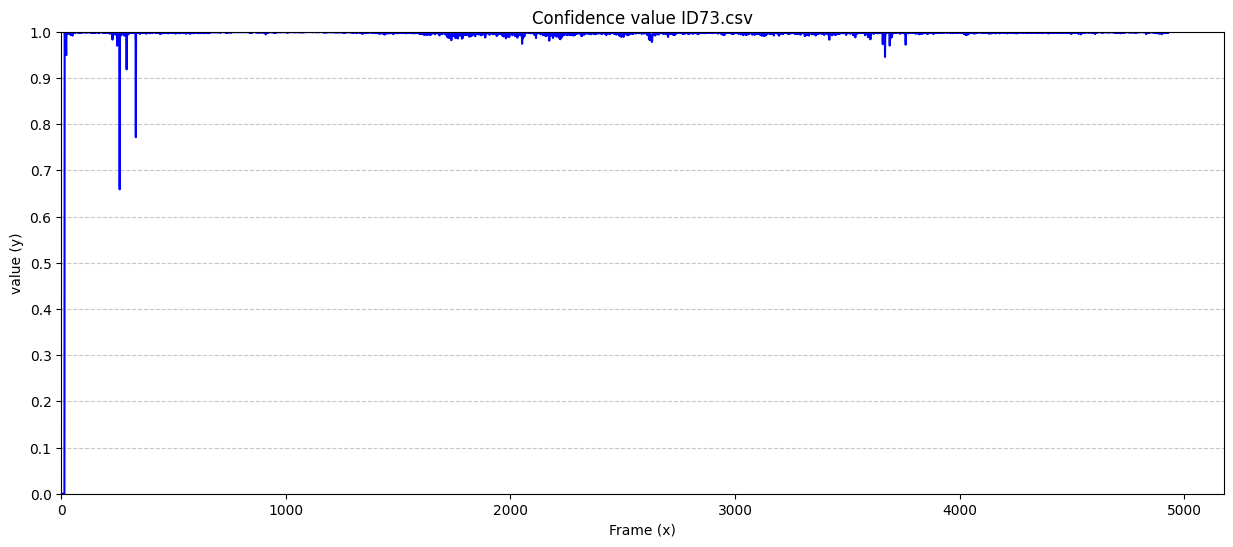

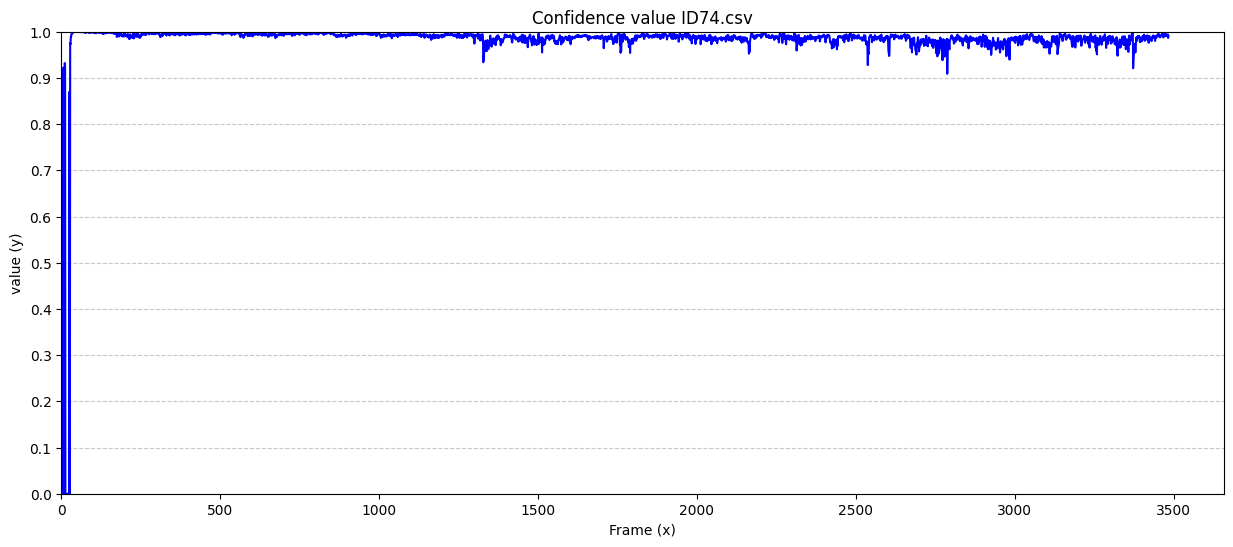

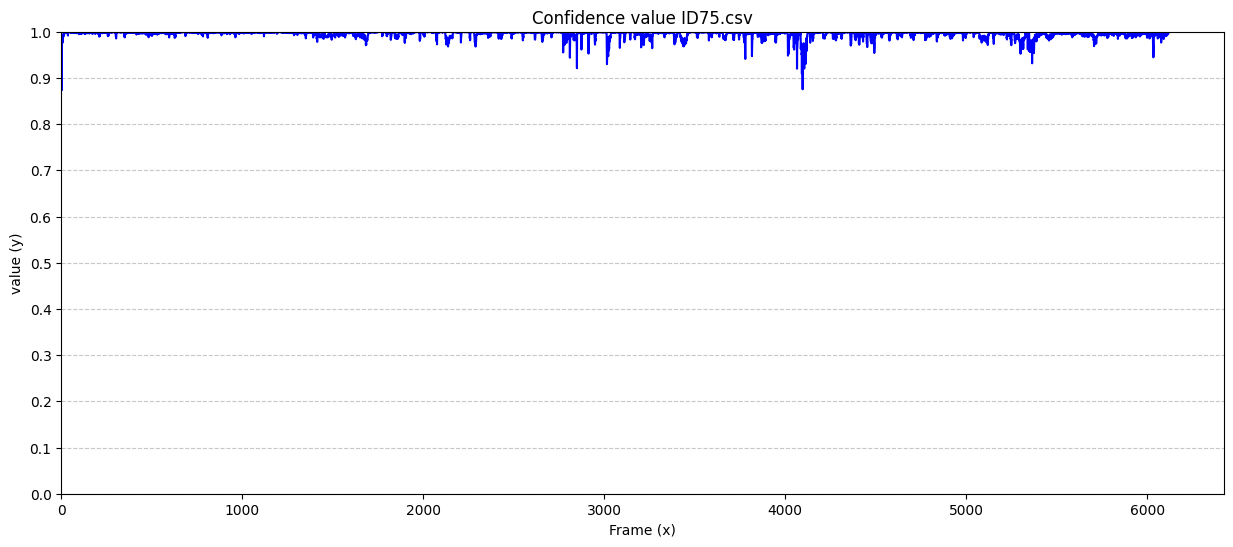

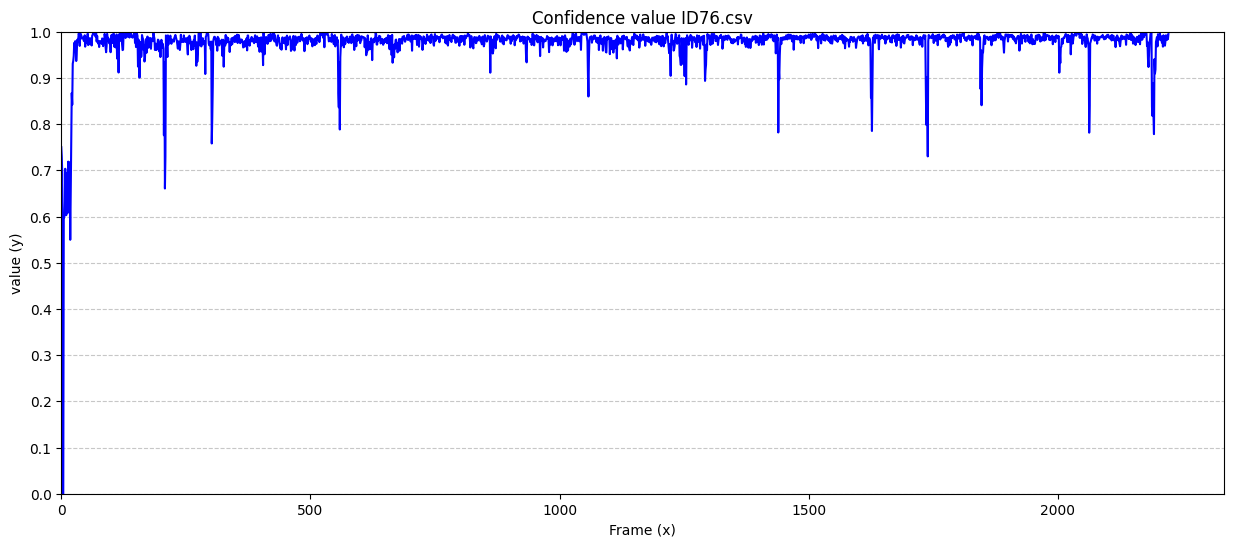

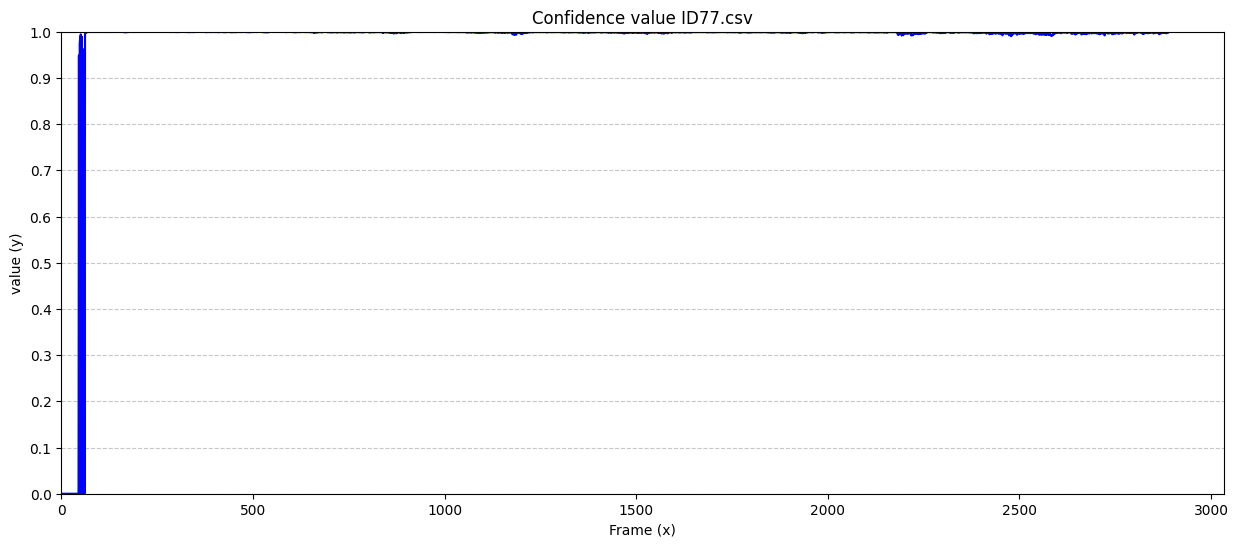

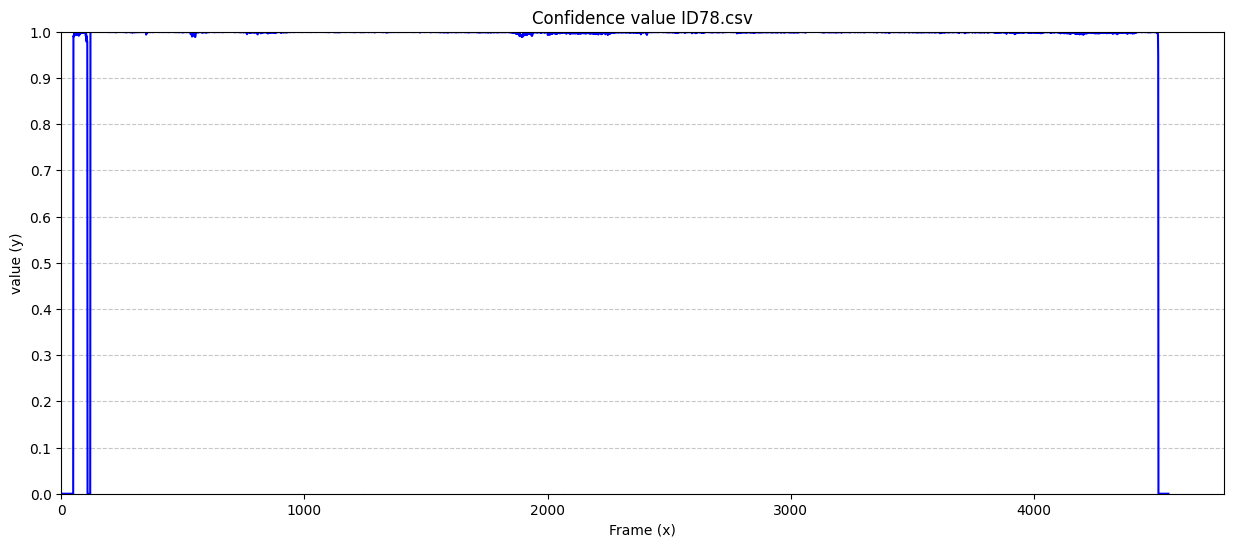

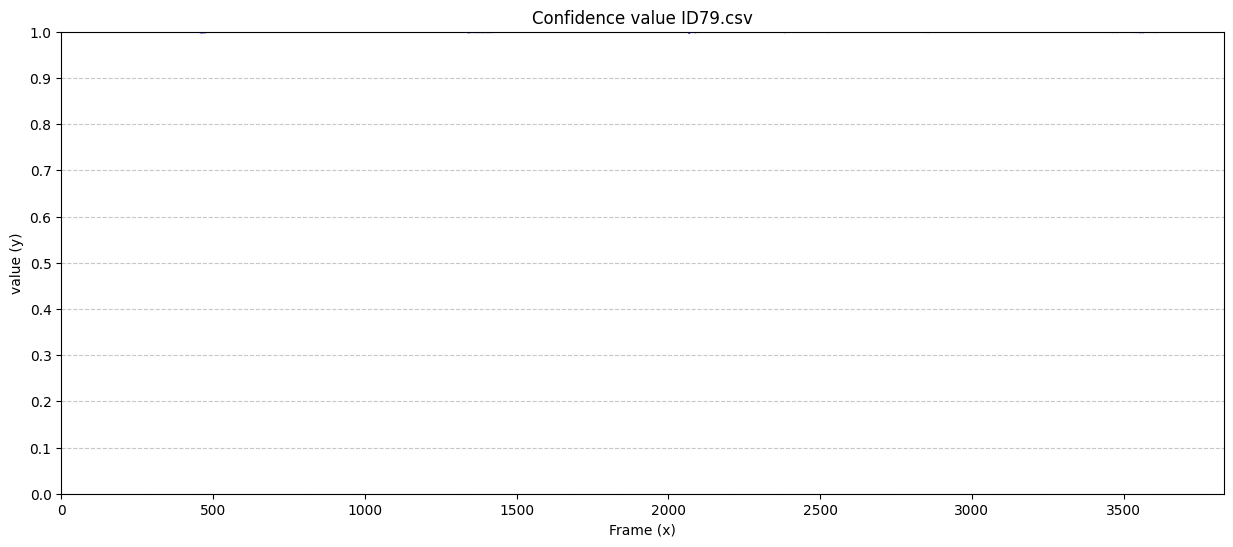

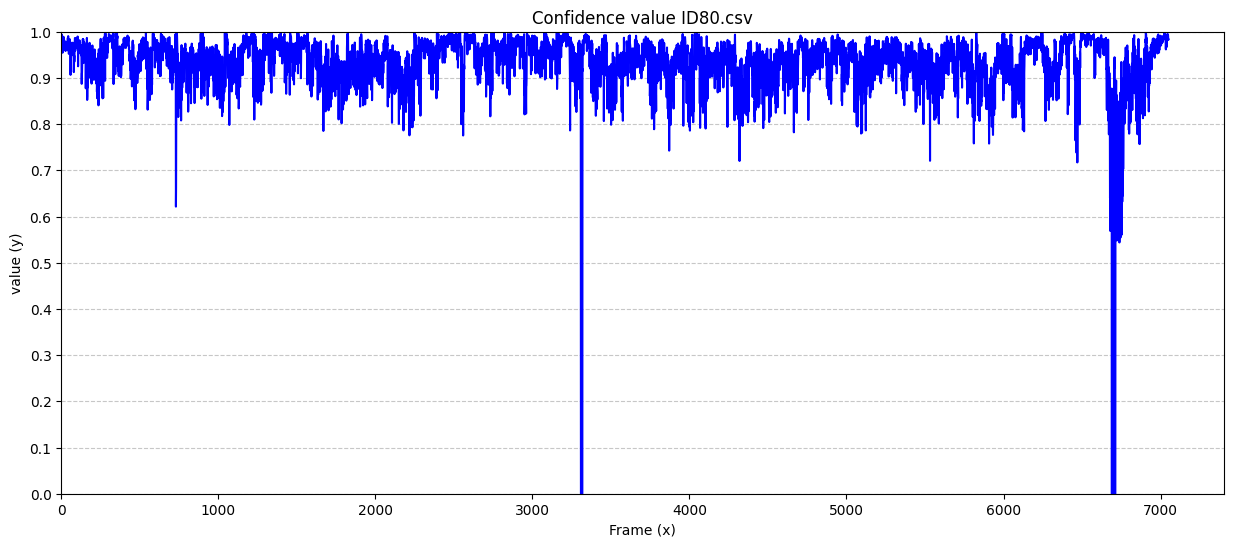

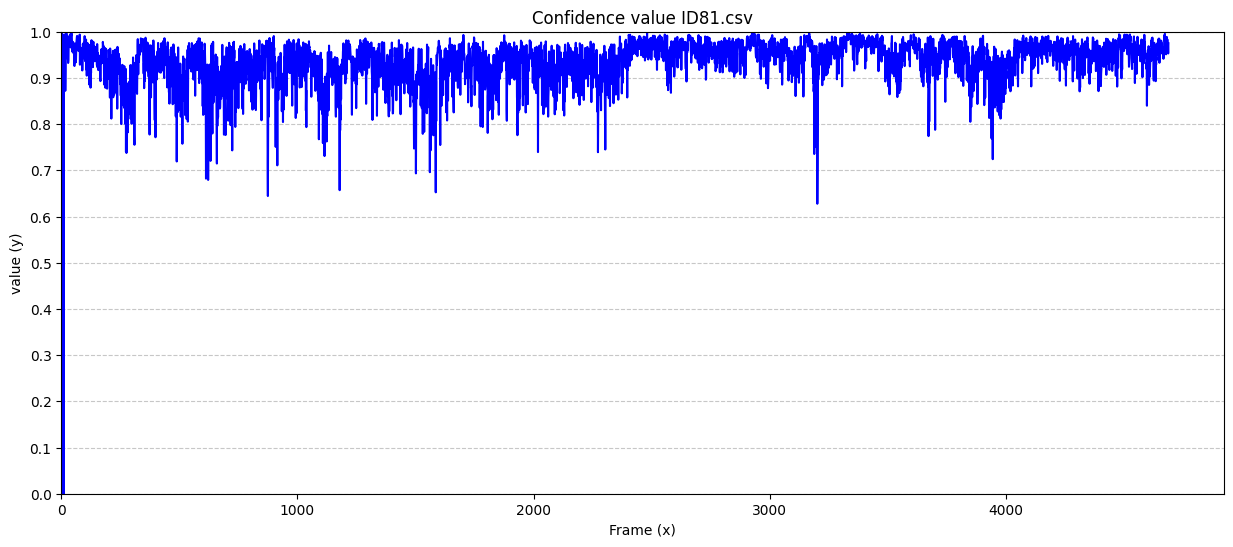

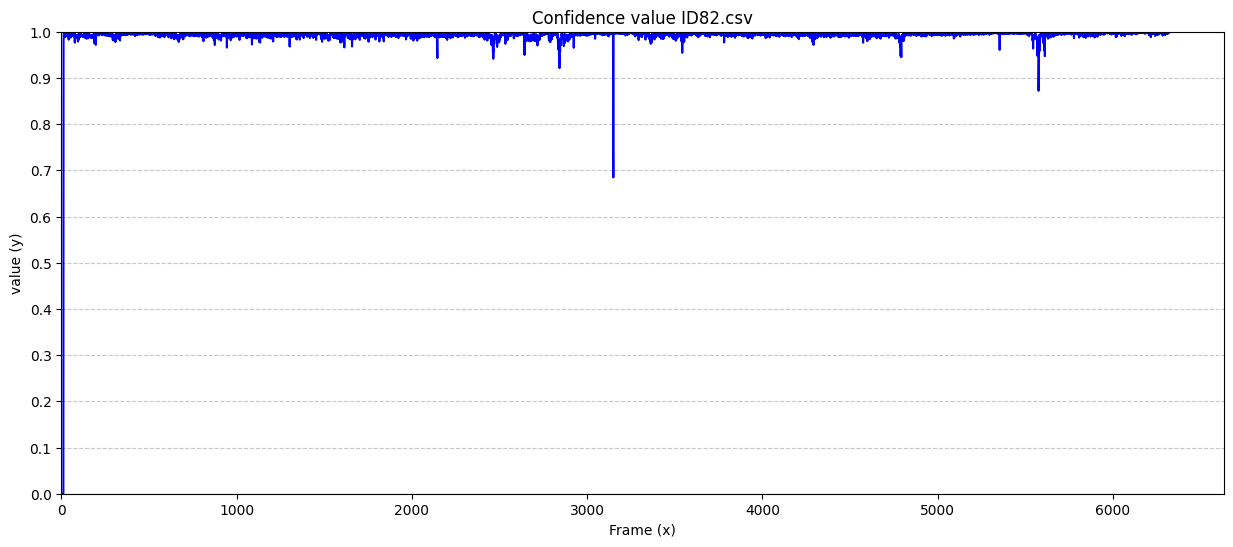

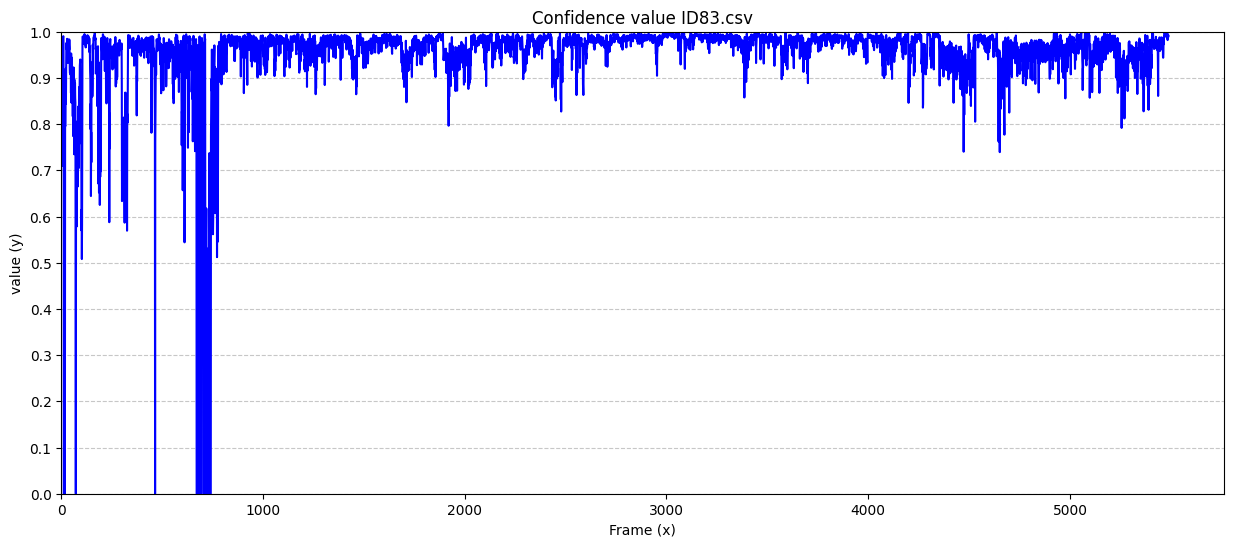

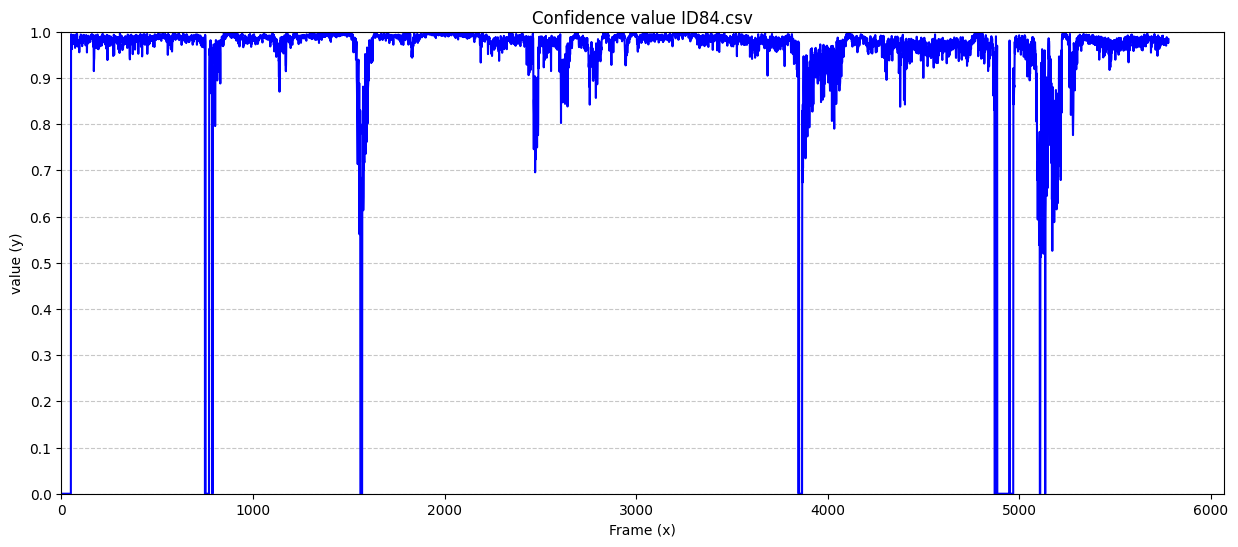

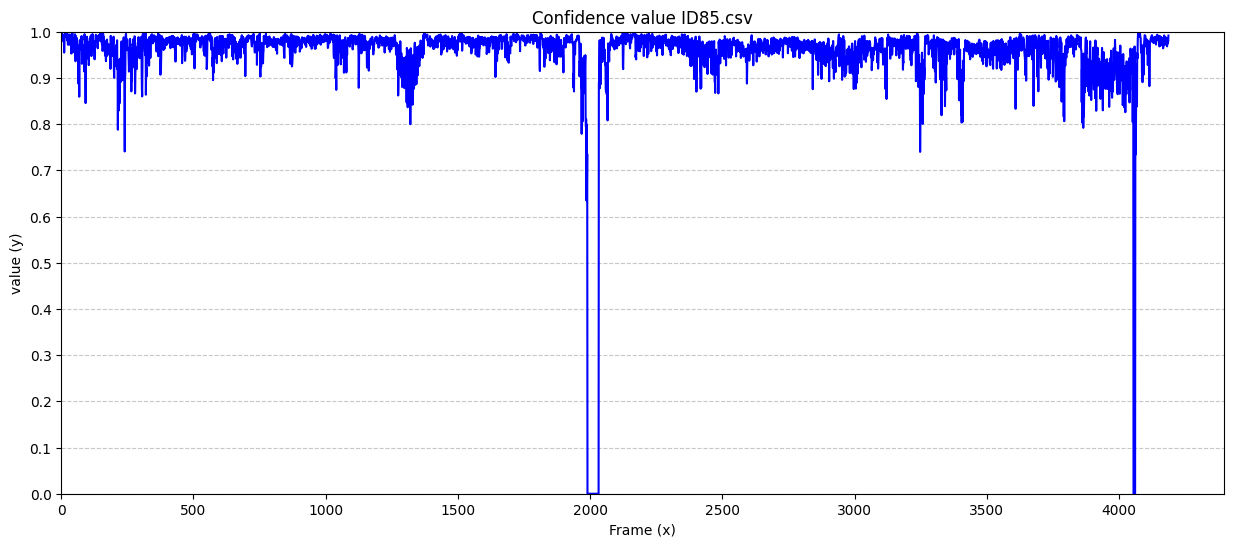

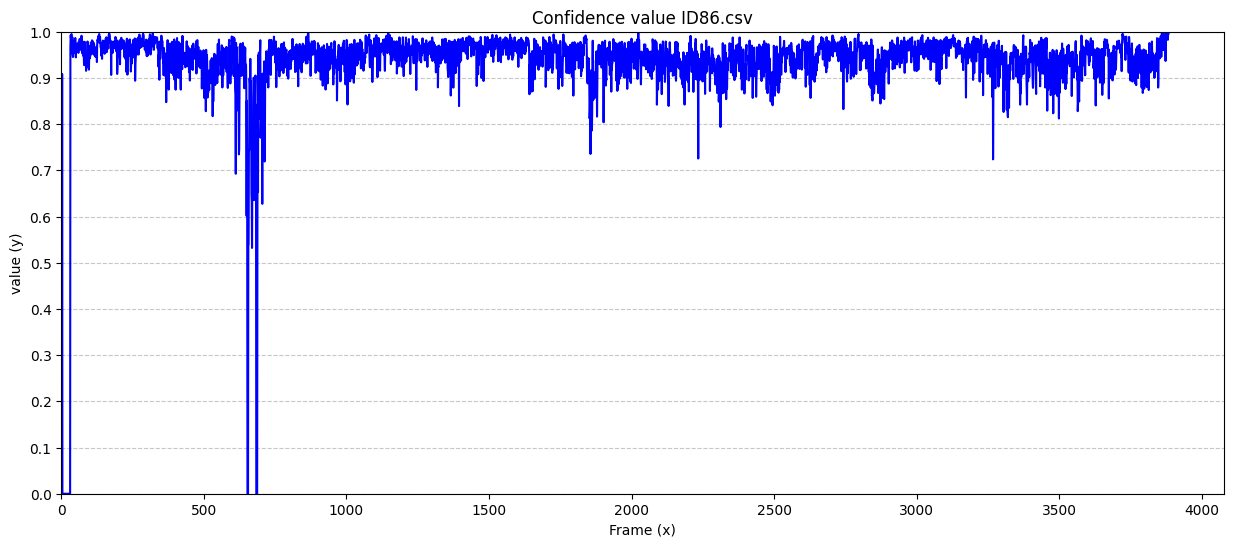

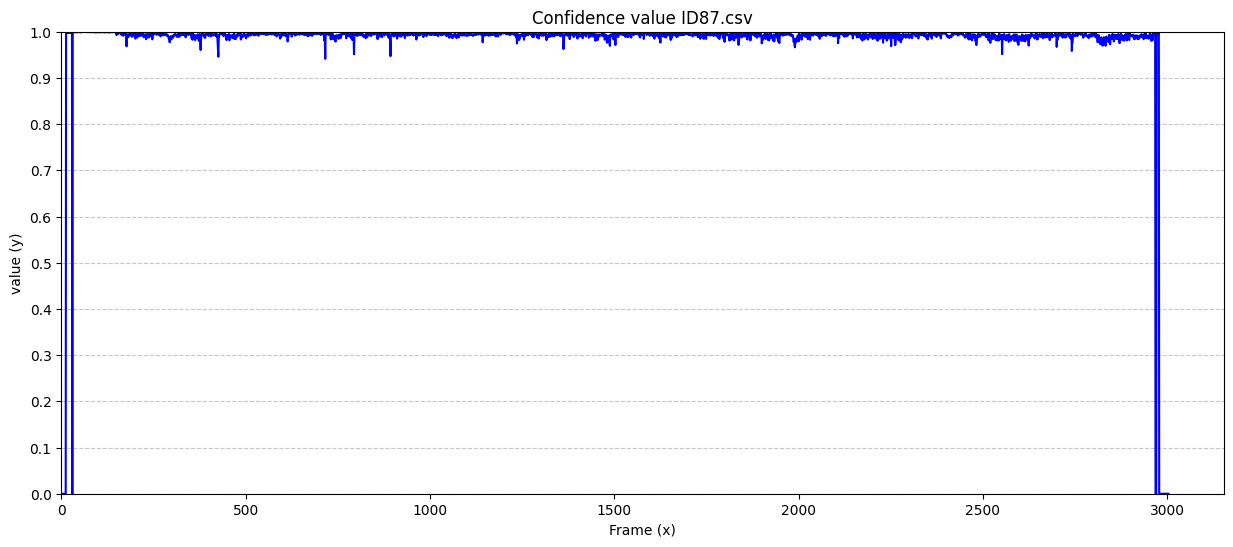

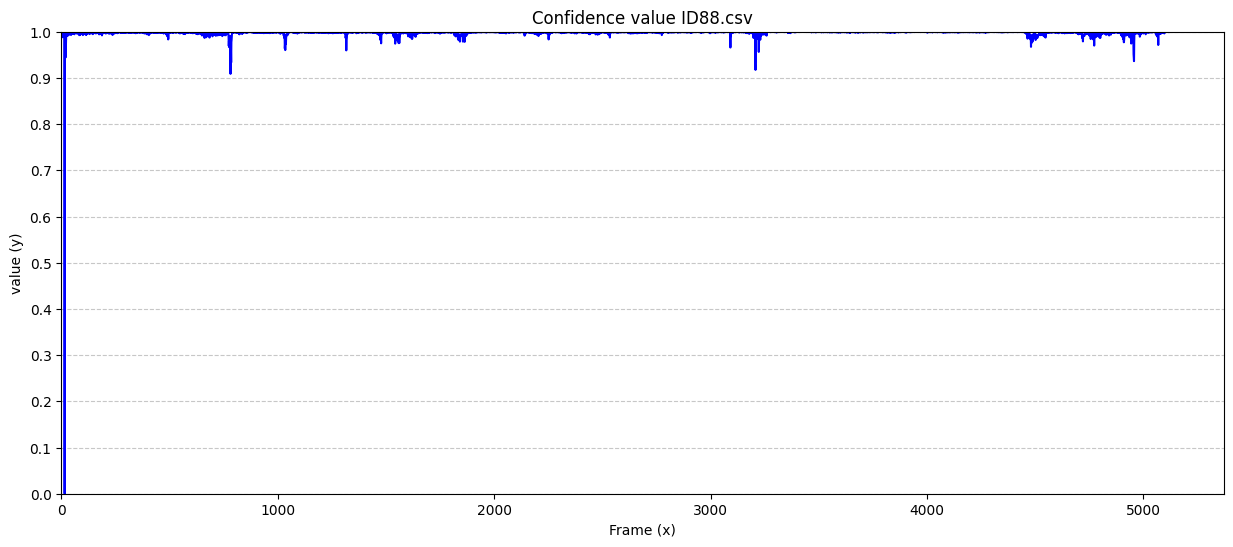

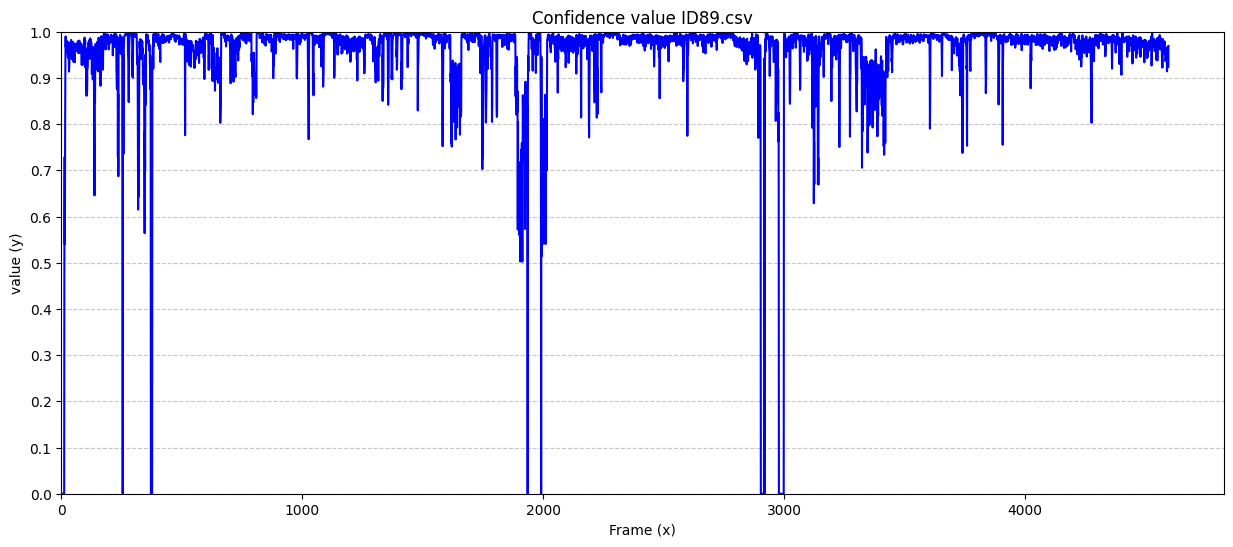

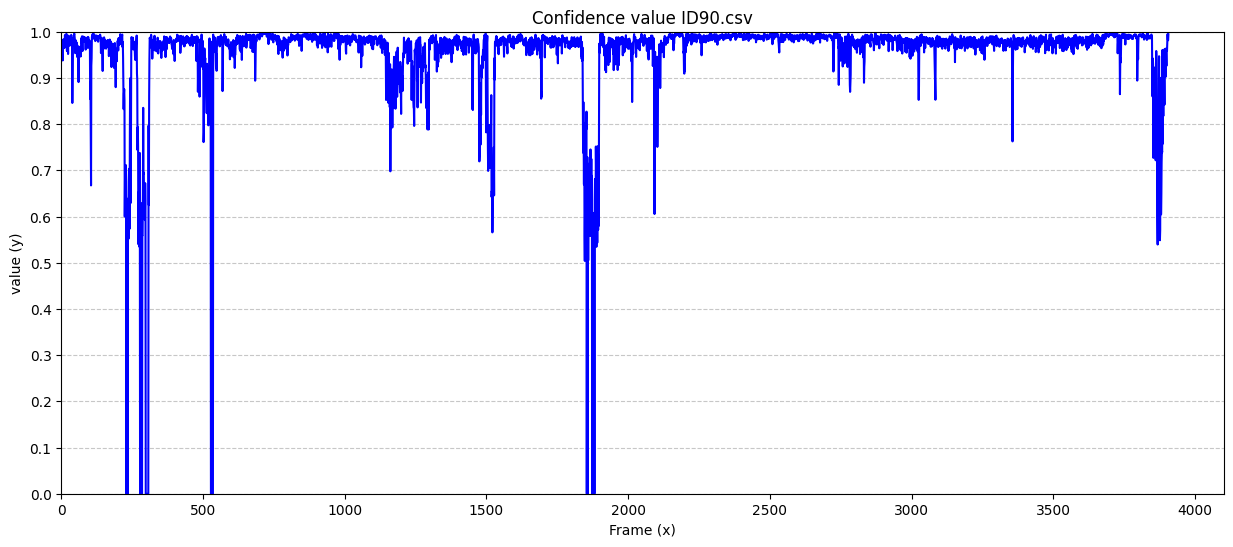

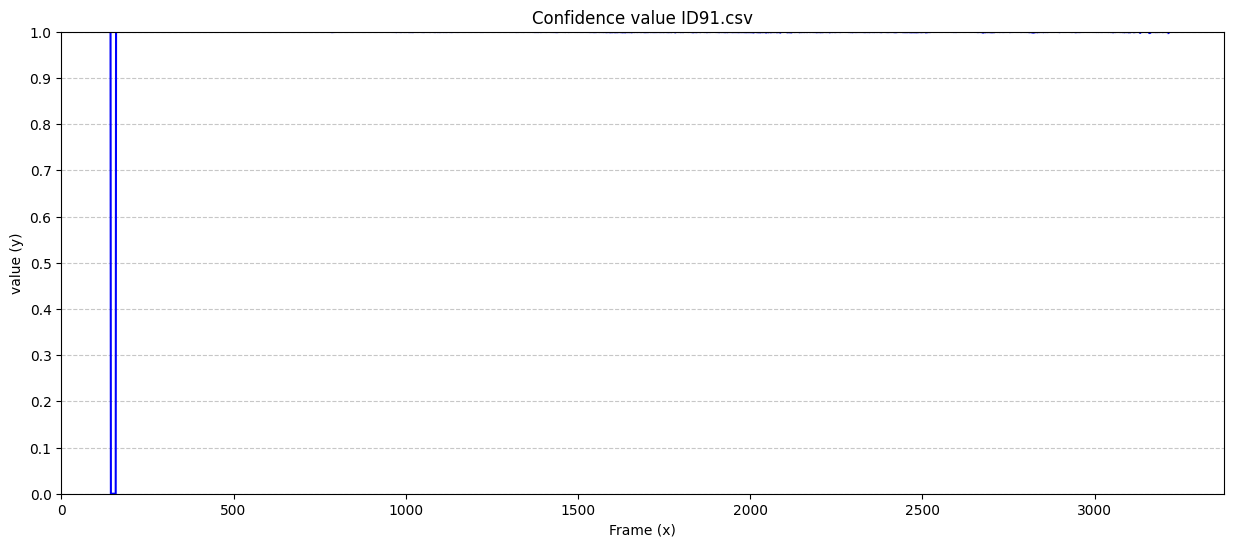

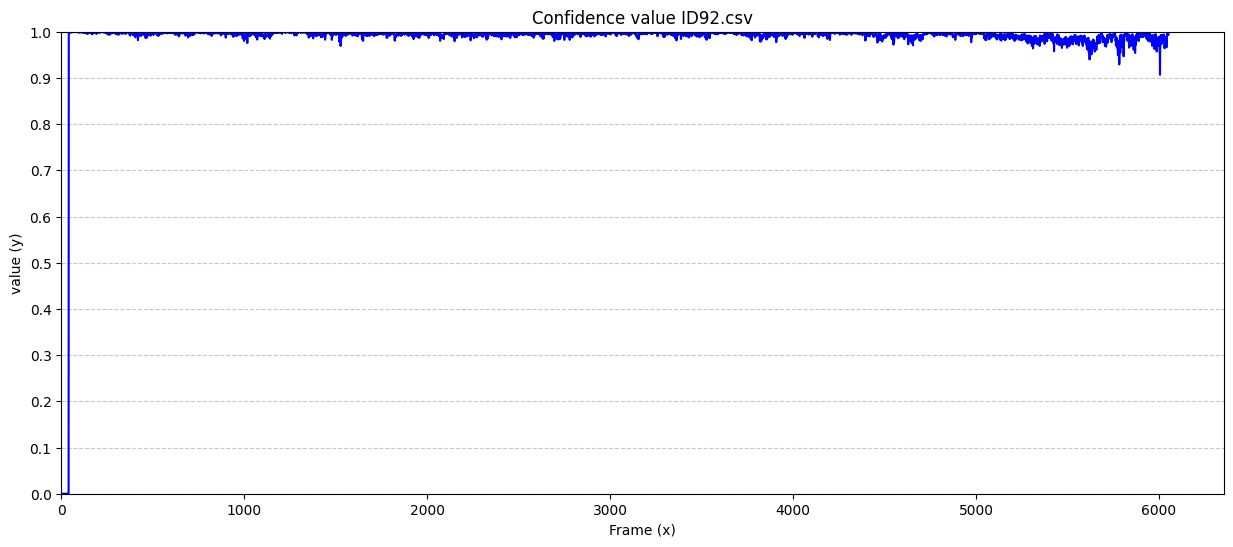

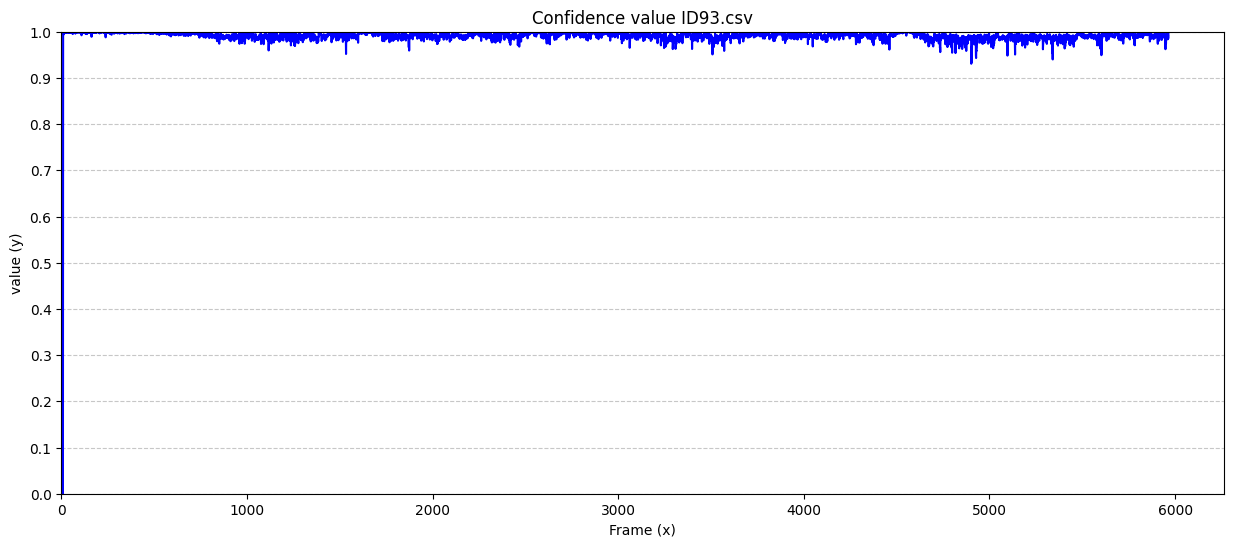

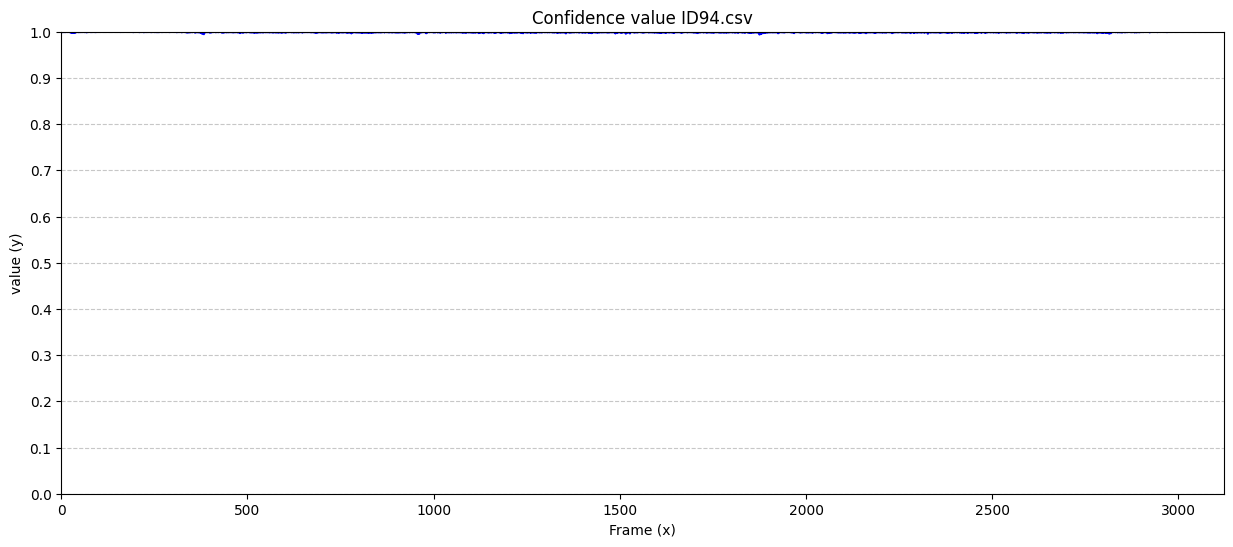

In [ ]:
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

file_path = Path('../../../face_data')

file_list = list(file_path.glob('*.csv'))
#print(file_list)

for f in file_list:
    df = pd.read_csv(f)
    filename = os.path.basename(f)
    #print(f)
    #print(df)
    y = df['Confidence']
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(df.index, y, label='Confidence', color='blue')

    ax.set_title(f'Confidence value {filename}')
    ax.set_xlabel('Frame (x)')
    ax.set_ylabel('value (y)')

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0, top=1)



    plt.show()

Confidenceが0.95を境にどれくらいあるのか

In [5]:
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys

# ログを保存するクラスを定義
class Logger:
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "a", encoding='utf-8') # "a"は追記モード

    def write(self, message):
        self.terminal.write(message) # 画面に出す
        self.log.write(message)      # ファイルに書く

    def flush(self):
        # このメソッドは必須（pythonの仕様）
        self.terminal.flush()
        self.log.flush()

# --- ここからメイン処理の前に記述 ---
# これ以降の print() やエラーはすべて 'output_log.txt' に保存されます
sys.stdout = Logger("Confidence0.95未満の割合.txt")
sys.stderr = Logger("Confidence0.95未満の割合.txt") # エラーも保存したい場合


file_path = Path('../../../face_data')

file_list = list(file_path.glob('*.csv'))
#print(file_list)

for f in file_list:
    df = pd.read_csv(f)
    filename = os.path.basename(f)
    #print(f)
    #print(df)
    y = df['Confidence']

    all_data_count = len(y)

    y_high = 0
    y_low = 0

    for i in range(all_data_count):
        if y[i] >= 0.95:
            y_high += 1
        else:
            y_low += 1
    
    print(f'---{filename}----')
    print(f'全フレーム数 : {all_data_count}')
    print(f'Confidence>=0.95 : {y_high}')
    print(f'Confidence<0.95 : {y_low}')
    print(f'0.95未満の割合 : {y_low*100/all_data_count:.2f}%')

    y_high =0
    y_low = 0


Confidence>=0.90でのデータ数チェック

In [3]:
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt

import sys

# ログを保存するクラスを定義
""" class Logger:
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "a", encoding='utf-8') # "a"は追記モード

    def write(self, message):
        self.terminal.write(message) # 画面に出す
        self.log.write(message)      # ファイルに書く

    def flush(self):
        # このメソッドは必須（pythonの仕様）
        self.terminal.flush()
        self.log.flush()

# --- ここからメイン処理の前に記述 ---
# これ以降の print() やエラーはすべて 'output_log.txt' に保存されます
sys.stdout = Logger("output_log_30_0.90.txt")
sys.stderr = Logger("output_log_30_0.90.txt") # エラーも保存したい場合

# --- 以下、いつものコード ---
print("これは画面にも出るし、ファイルにも保存されます") """
# ...

file_path = Path('../../../output_filtered_questions_copy')

file_list = list(file_path.glob('*.csv'))
#print(file_list)

for f in file_list:
    df = pd.read_csv(f)
    filename = os.path.basename(f)

    print(f"------{filename}の処理------")
    df['label'] = df['label'].astype(str).str.strip()
    df_answer = df[df['label'].str.match('^answer(10|[1-9])$', na=False)]

    df_answer = df_answer.copy()

    df_answer["label"] = pd.Categorical(
        df_answer["label"],
        categories=[f"answer{i}" for i in range(1, 11)],
        ordered=True
    )

    #　先頭30フレームを抽出してから、Confidence>=0.90を抽出 (or Confidence>=0.90を抽出してから、先頭30フレームを抽出)
    """ df_30frame_answer = (
        df_answer.groupby("label", group_keys=False, as_index=False, observed=True)
        .head(30)
        .reset_index(drop=True)
    ) """
    df_frame_count = df_answer.groupby("label", observed=True).size()

    df_frame_confidence = df_answer[df_answer['Confidence']>=0.95]
    df_frame_confidence_count = df_frame_confidence.groupby('label', observed=True).size()

    
    print('フレーム数を出力')
    print(df_frame_count)
    print('Confidence>=0.95を抽出')
    print(df_frame_confidence_count)

In [6]:
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt

""" import sys

# ログを保存するクラスを定義
class Logger:
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "a", encoding='utf-8') # "a"は追記モード

    def write(self, message):
        self.terminal.write(message) # 画面に出す
        self.log.write(message)      # ファイルに書く

    def flush(self):
        # このメソッドは必須（pythonの仕様）
        self.terminal.flush()
        self.log.flush()

# --- ここからメイン処理の前に記述 ---
# これ以降の print() やエラーはすべて 'output_log.txt' に保存されます
sys.stdout = Logger("output_log_0.95_30.txt")
sys.stderr = Logger("output_log_0.90_30.txt") # エラーも保存したい場合 """

file_path = Path('../../../output_filtered_questions_copy')

file_list = list(file_path.glob('*.csv'))
#print(file_list)
output_df = pd.DataFrame()
for f in file_list:
    df = pd.read_csv(f)
    filename = os.path.basename(f)

    print(f"------{filename}の処理------")
    df['label'] = df['label'].astype(str).str.strip()
    df_answer = df[df['label'].str.match('^answer(10|[1-9])$', na=False)]

    df_answer = df_answer.copy()

    df_answer["label"] = pd.Categorical(
        df_answer["label"],
        categories=[f"answer{i}" for i in range(1, 11)],
        ordered=True
    )

    df_answer_confidence = df_answer[df_answer['Confidence']>=0.95]

    """ df_answer_confidence_30frame = (
        df_answer_confidence.groupby("label", group_keys=False, as_index=False, observed=True)
        .head(30)
        .reset_index(drop=True)
    ) """
    df_answer_confidence_frame_count = df_answer_confidence.groupby('label', observed=True).size()
    print(df_answer_confidence_frame_count)
""" 
    output_df = pd.concat([output_df, df_answer_confidence_30frame_count], ignore_index=True)

output_filename = '0.90以上の先頭30フレーム.csv'
output_df.reset_index(inplace=True)
output_df.to_csv(output_filename, index=False, encoding='utf-8-sig') """


    

    #　先頭30フレームを抽出してから、Confidence>=0.90を抽出 (or Confidence>=0.90を抽出してから、先頭30フレームを抽出)
"""     df_30frame_answer = (
        df_answer.groupby("label", group_keys=False, as_index=False, observed=True)
        .head(30)
        .reset_index(drop=True)
    )
    df_30frame_count = df_30frame_answer.groupby("label", observed=True).size()

    df_30frame_confidence = df_30frame_answer[df_30frame_answer['Confidence']>=0.90]
    df_30frame_confidence_count = df_30frame_confidence.groupby('label', observed=True).size()

    
    print('先頭30フレームを抽出')
    print(df_30frame_count)
    print('Confidence>=0.90を抽出')
    print(df_30frame_confidence_count) """

'     df_30frame_answer = (\n        df_answer.groupby("label", group_keys=False, as_index=False, observed=True)\n        .head(30)\n        .reset_index(drop=True)\n    )\n    df_30frame_count = df_30frame_answer.groupby("label", observed=True).size()\n\n    df_30frame_confidence = df_30frame_answer[df_30frame_answer[\'Confidence\']>=0.90]\n    df_30frame_confidence_count = df_30frame_confidence.groupby(\'label\', observed=True).size()\n\n\n    print(\'先頭30フレームを抽出\')\n    print(df_30frame_count)\n    print(\'Confidence>=0.90を抽出\')\n    print(df_30frame_confidence_count) '

In [1]:
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt

file_path = Path('../../../output_filtered_questions_copy')

file_list = list(file_path.glob('*.csv'))
#print(file_list)
for f in file_list:
    df = pd.read_csv(f)
    filename = os.path.basename(f)

    print(f"------{filename}の処理------")
    df['label'] = df['label'].astype(str).str.strip()
    df_answer = df[df['label'].str.match('^answer(10|[1-9])$', na=False)]

    df_answer = df_answer.copy()

    df_answer["label"] = pd.Categorical(
        df_answer["label"],
        categories=[f"answer{i}" for i in range(1, 11)],
        ordered=True
    )

    df_answer_confidence = df_answer[df_answer['Confidence']>=0.95]
    df_answer_confidence_frame_count = df_answer_confidence.groupby('label', observed=True).size()
    print(df_answer_confidence_frame_count)
    print(f)

------filtered_ID30.csvの処理------
label
answer1       57
answer2      206
answer3       49
answer4      151
answer5      471
answer6      674
answer7      197
answer8      373
answer9      234
answer10    1118
dtype: int64
..\..\..\output_filtered_questions_copy\filtered_ID30.csv
------filtered_ID31.csvの処理------
label
answer1        8
answer2      356
answer3       47
answer4      199
answer5      795
answer6      137
answer7      325
answer8       37
answer9      514
answer10    1640
dtype: int64
..\..\..\output_filtered_questions_copy\filtered_ID31.csv
------filtered_ID32.csvの処理------
label
answer1      153
answer2      122
answer3      238
answer4      518
answer5       88
answer6      507
answer7      570
answer8      500
answer9      734
answer10    1290
dtype: int64
..\..\..\output_filtered_questions_copy\filtered_ID32.csv
------filtered_ID33.csvの処理------
label
answer1      66
answer2     142
answer3     234
answer4      29
answer5      31
answer6     418
answer7      88
answer8  